# Lifted Heston calibration notebook

This notebook rebuilds the **lifted Heston calibration** from scratch in a cleaner and more modular way.

Design goals:

- keep a **single calibration pipeline**,
- use **mid prices as the source of truth** and recompute Black-Scholes IVs from those prices,
- keep the **time convention explicit**: calendar days for maturity fractions, 252 steps per year for Monte Carlo time stepping,
- use a **plain Heston fit only as a warm start** for the lifted model,
- keep **common random numbers** fixed during Monte Carlo calibration so the optimiser sees a stable objective,
- separate:
  1. data loading,
  2. target construction,
  3. Heston warm start,
  4. lifted Heston calibration,
  5. diagnostics.

This is **Part 1** of the larger dissertation workflow. It only handles the calibration block cleanly.


In [1]:
from __future__ import annotations

from dataclasses import dataclass, asdict
from pathlib import Path
import math
import warnings
import json
import os


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.integrate import quad
from scipy.optimize import Bounds, LinearConstraint, brentq, least_squares, minimize, nnls
from scipy.special import ndtr

warnings.filterwarnings("ignore")

try:
    from joblib import Parallel, delayed
    HAVE_JOBLIB = True
except Exception:
    Parallel = None
    delayed = None
    HAVE_JOBLIB = False


try:
    from scipy.stats import qmc, norm as scipy_stats_norm
    HAVE_QMC = True
except Exception:
    qmc = None
    scipy_stats_norm = None
    HAVE_QMC = False

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 180)
pd.set_option("display.float_format", lambda x: f"{x:,.6f}")

CALENDAR_DAYS_PER_YEAR = 365.25
SIMULATION_STEPS_PER_YEAR = 252

@dataclass
class CalibrationConfig:
    seed: int = 42
    r: float = 0.01

    calendar_days_per_year: float = CALENDAR_DAYS_PER_YEAR
    simulation_steps_per_year: int = SIMULATION_STEPS_PER_YEAR

    target_dte: int = 30
    min_dte: int = 7
    max_dte: int = 180
    max_rel_spread: float = 0.15
    max_m_gap: float = 0.12
    min_best_bid: float = 0.05
    min_open_interest: int = 1
    use_otm_quotes: bool = True

    iv_gap_floor: float = 0.010
    iv_gap_mad_multiplier: float = 3.0

    fit_weight_floor: float = 0.25
    fit_weight_cap: float = 4.0

    arb_price_tolerance: float = 1e-6
    no_arb_repair: bool = True
    no_arb_repair_maxiter: int = 600

    min_points: int = 8
    max_maturities: int = 6
    strikes_per_maturity: int = 7
    max_candidate_strikes_per_maturity: int = 12

    n_factors: int = 4
    H_grid: tuple[float, ...] = (0.05, 0.08, 0.12, 0.16)

    w_price: float = 1.0
    w_iv: float = 8.0
    vega_floor: float = 1.0

    heston_max_nfev: int = 250
    lifted_parallel_jobs: int = -1
    lifted_parallel_prefer: str = "processes"
    lifted_powell_maxiter: int = 35
    lifted_lbfgsb_maxiter: int = 120

    lifted_mc_paths_fit: int = 1024
    lifted_mc_paths_eval: int = 2048
    use_sobol: bool = True
    use_antithetic: bool = True

    option_parquet_batch_size: int = 250_000
    option_csv_chunk_size: int = 750_000
    option_scan_top_dates: int = 24
    option_eval_top_dates: int = 12
    debug_date_min: str | None = None
    debug_date_max: str | None = None

    option_candidates: tuple[str, ...] = (
        "optionmetrics_30d_atm_slice.parquet",
        "OptionMetrics ATM IV 2010 - 2025.parquet",
        "optionmetrics_atm_iv_2010_2025.parquet",
        "optionmetrics.parquet",
        "OptionMetrics ATM IV 2010 - 2025.csv",
        "optionmetrics_atm_iv_2010_2025.csv",
        "optionmetrics.csv",
    )
    crsp_candidates: tuple[str, ...] = (
        "crsp_sp_daily.parquet",
        "CRSP S&P 2010 - 2024.parquet",
        "crsp_sp_2010_2024.parquet",
        "crsp.parquet",
        "CRSP S&P 2010 - 2024.csv",
        "crsp_sp_2010_2024.csv",
        "crsp.csv",
    )

CFG = CalibrationConfig()
np.random.seed(CFG.seed)

OUTPUT_DIR = Path("lifted_heston_calibration_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR = OUTPUT_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)


# Fast iteration preset
# CFG = CalibrationConfig(H_grid=(0.08, 0.12), lifted_mc_paths_fit=192, lifted_mc_paths_eval=512, lifted_powell_maxiter=20, lifted_lbfgsb_maxiter=60)

## 1. Load and clean the option inputs

The loader is intentionally boring.

- Prefer a pre-sliced ATM parquet file if you have one.
- If only a CSV exists, read only the columns we need.
- Convert everything once.
- Build one cleaned options panel and one cleaned CRSP panel.


In [2]:
OPTION_REQUIRED_COLS = [
    "date", "exdate", "cp_flag", "strike_price", "best_bid", "best_offer",
    "impl_volatility", "delta", "forward_price", "open_interest"
]
OPTION_SCORE_COLS = [
    "date", "exdate", "cp_flag", "strike_price", "best_bid", "best_offer",
    "delta", "open_interest"
]
CRSP_REQUIRED_COLS = ["caldt", "date", "sprtrn", "ret", "spindx"]

def first_existing(candidates, roots=None):
    roots = [Path(".")] if roots is None else [Path(r) for r in roots]
    for root in roots:
        for name in candidates:
            p = root / name
            if p.exists():
                return p
    for root in roots:
        for name in candidates:
            hits = list(root.rglob(name))
            if hits:
                return hits[0]
    return None

def _coerce_numeric(df, cols):
    for c in cols:
        if c in df.columns:
            s = pd.to_numeric(df[c], errors="coerce")
            kind = getattr(s.dtype, "kind", "")
            if kind in ("i", "u"):
                s = pd.to_numeric(s, downcast="integer")
            elif kind == "f":
                s = pd.to_numeric(s, downcast="float")
            df[c] = s
    return df

def parquet_available_columns(path: Path):
    try:
        import pyarrow.parquet as pq
        return list(pq.ParquetFile(path).schema.names)
    except Exception:
        return []

def _maybe_to_datetime(series):
    if pd.api.types.is_datetime64_any_dtype(series):
        return pd.to_datetime(series, errors="coerce")
    return pd.to_datetime(series, errors="coerce")

def _maybe_apply_debug_date_filter(x: pd.DataFrame, cfg: CalibrationConfig) -> pd.DataFrame:
    if x is None or x.empty or "date" not in x.columns:
        return pd.DataFrame() if x is None else x

    date_min = pd.Timestamp(cfg.debug_date_min) if getattr(cfg, "debug_date_min", None) else None
    date_max = pd.Timestamp(cfg.debug_date_max) if getattr(cfg, "debug_date_max", None) else None

    if date_min is not None:
        x = x.loc[x["date"] >= date_min]
    if date_max is not None:
        x = x.loc[x["date"] <= date_max]
    return x


def _iter_option_source_chunks(path: Path, cfg: CalibrationConfig = CFG, columns=None):
    if path is None:
        return
    columns = list(columns) if columns is not None else list(OPTION_REQUIRED_COLS)

    if path.suffix.lower() == ".parquet":
        import pyarrow.parquet as pq

        available = set(parquet_available_columns(path))
        cols = [c for c in columns if c in available] if available else [c for c in columns if c]
        pf = pq.ParquetFile(path)
        batch_size = int(getattr(cfg, "option_parquet_batch_size", 250_000))

        for batch in pf.iter_batches(columns=cols, batch_size=batch_size, use_threads=True):
            yield batch.to_pandas()
        return

    csv_chunk_size = int(getattr(cfg, "option_csv_chunk_size", 750_000))
    for chunk in pd.read_csv(
        path,
        usecols=lambda c: c in set(columns),
        chunksize=csv_chunk_size,
        low_memory=False,
    ):
        yield chunk

def prepare_option_score_chunk(chunk: pd.DataFrame, cfg: CalibrationConfig = CFG) -> pd.DataFrame:
    if chunk is None or chunk.empty:
        return pd.DataFrame()

    keep = [c for c in OPTION_SCORE_COLS if c in chunk.columns]
    if {"date", "exdate", "cp_flag"} - set(keep):
        return pd.DataFrame()

    x = chunk.loc[:, keep].copy()
    x["date"] = _maybe_to_datetime(x["date"])
    x["exdate"] = _maybe_to_datetime(x["exdate"])
    x = x.loc[x["date"].notna() & x["exdate"].notna()]
    if x.empty:
        return pd.DataFrame()

    x = _maybe_apply_debug_date_filter(x, cfg)
    if x.empty:
        return pd.DataFrame()

    x = _coerce_numeric(x, ["strike_price", "best_bid", "best_offer", "delta", "open_interest"])

    x["dte"] = (x["exdate"] - x["date"]).dt.days.astype("float32")
    x = x.loc[(x["dte"] > 0) & x["dte"].between(cfg.min_dte, cfg.max_dte)]
    if x.empty:
        return pd.DataFrame()

    x["strike"] = (x["strike_price"] / 1000.0).astype("float32")
    x["mid"] = ((x["best_bid"] + x["best_offer"]) / 2.0).astype("float32")
    x["spread"] = (x["best_offer"] - x["best_bid"]).astype("float32")
    x["rel_spread"] = np.where(x["mid"] > 0, x["spread"] / x["mid"], np.nan).astype("float32")
    x["abs_delta"] = x["delta"].abs().astype("float32")

    if "open_interest" in x.columns:
        x["open_interest"] = pd.to_numeric(x["open_interest"], errors="coerce", downcast="integer")
        oi_ok = x["open_interest"].isna() | (x["open_interest"] >= cfg.min_open_interest)
    else:
        oi_ok = True

    liquidity_ok = (
        (x["best_offer"] >= x["best_bid"])
        & x["mid"].notna()
        & (x["mid"] > 0)
        & (x["best_bid"] >= cfg.min_best_bid)
        & x["strike"].notna()
        & (x["strike"] > 0)
        & x["abs_delta"].between(0.01, 0.99)
        & (x["rel_spread"].isna() | (x["rel_spread"] <= cfg.max_rel_spread))
        & oi_ok
    )

    x = x.loc[liquidity_ok]
    if x.empty:
        return pd.DataFrame()

    out = x.loc[:, ["date", "dte", "mid", "rel_spread", "abs_delta"]].copy()
    out["delta_gap"] = (out["abs_delta"] - 0.50).abs().astype("float32")
    return out.reset_index(drop=True)

def scan_option_candidate_dates(path: Path, cfg: CalibrationConfig = CFG) -> pd.DataFrame:
    if path is None:
        return pd.DataFrame(columns=["date", "n_quotes", "n_maturities", "mean_delta_gap", "mean_rel_spread"])

    stats = {}

    for raw_chunk in _iter_option_source_chunks(path, cfg=cfg, columns=OPTION_SCORE_COLS):
        chunk = prepare_option_score_chunk(raw_chunk, cfg=cfg)
        if chunk.empty:
            continue

        grouped = chunk.groupby("date", sort=False)
        for dt, g in grouped:
            rec = stats.get(dt)
            if rec is None:
                rec = {"n_quotes": 0, "sum_delta_gap": 0.0, "sum_rel_spread": 0.0, "dtes": set()}
                stats[dt] = rec

            rec["n_quotes"] += int(len(g))
            rec["sum_delta_gap"] += float(g["delta_gap"].sum())
            rec["sum_rel_spread"] += float(g["rel_spread"].fillna(0.0).sum())
            rec["dtes"].update(pd.Series(g["dte"]).dropna().astype(int).tolist())

    if not stats:
        return pd.DataFrame(columns=["date", "n_quotes", "n_maturities", "mean_delta_gap", "mean_rel_spread"])

    rows = []
    for dt, rec in stats.items():
        n_quotes = max(int(rec["n_quotes"]), 1)
        rows.append({
            "date": pd.Timestamp(dt),
            "n_quotes": int(rec["n_quotes"]),
            "n_maturities": int(len(rec["dtes"])),
            "mean_delta_gap": float(rec["sum_delta_gap"] / n_quotes),
            "mean_rel_spread": float(rec["sum_rel_spread"] / n_quotes),
        })

    scores = pd.DataFrame(rows).sort_values(
        ["n_maturities", "n_quotes", "mean_delta_gap", "mean_rel_spread"],
        ascending=[False, False, True, True],
    ).reset_index(drop=True)

    top_n = int(getattr(cfg, "option_scan_top_dates", 24))
    return scores.head(max(top_n, 1)).reset_index(drop=True)

def load_option_data_for_dates(path: Path, dates, cfg: CalibrationConfig = CFG) -> pd.DataFrame:
    if path is None:
        return pd.DataFrame()

    if dates is None:
        selected = None
    else:
        selected = {pd.Timestamp(d).normalize() for d in list(dates)}
        if not selected:
            return pd.DataFrame()

    frames = []
    for raw_chunk in _iter_option_source_chunks(path, cfg=cfg, columns=OPTION_REQUIRED_COLS):
        chunk = prepare_option_chunk(raw_chunk, cfg=cfg)
        if chunk.empty:
            continue
        if selected is not None:
            chunk = chunk.loc[chunk["date"].dt.normalize().isin(selected)]
            if chunk.empty:
                continue
        frames.append(chunk)

    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()

def prepare_option_chunk(chunk: pd.DataFrame, cfg: CalibrationConfig = CFG) -> pd.DataFrame:
    if chunk is None or chunk.empty:
        return pd.DataFrame()

    keep = [c for c in OPTION_REQUIRED_COLS if c in chunk.columns]
    if not keep:
        return pd.DataFrame()

    x = chunk.loc[:, keep].copy()
    if {"date", "exdate", "cp_flag"} - set(x.columns):
        return pd.DataFrame()

    x["date"] = _maybe_to_datetime(x["date"])
    x["exdate"] = _maybe_to_datetime(x["exdate"])
    x = x.loc[x["date"].notna() & x["exdate"].notna()]
    if x.empty:
        return pd.DataFrame()

    x = _maybe_apply_debug_date_filter(x, cfg)
    if x.empty:
        return pd.DataFrame()

    x = _coerce_numeric(
        x,
        ["strike_price", "best_bid", "best_offer", "impl_volatility", "delta", "forward_price", "open_interest"],
    )

    x["cp_flag"] = (
        x["cp_flag"]
        .astype(str)
        .str.upper()
        .str.strip()
        .str[0]
        .astype("category")
    )

    x["dte"] = (x["exdate"] - x["date"]).dt.days.astype("float32")
    x = x.loc[(x["dte"] > 0) & x["dte"].between(cfg.min_dte, cfg.max_dte)].copy()
    if x.empty:
        return pd.DataFrame()

    x["strike"] = (x["strike_price"] / 1000.0).astype("float32")
    x["mid"] = ((x["best_bid"] + x["best_offer"]) / 2.0).astype("float32")
    x["spread"] = (x["best_offer"] - x["best_bid"]).astype("float32")
    x["rel_spread"] = np.where(x["mid"] > 0, x["spread"] / x["mid"], np.nan).astype("float32")
    x["abs_delta"] = x["delta"].abs().astype("float32")

    if "open_interest" in x.columns:
        x["open_interest"] = pd.to_numeric(x["open_interest"], errors="coerce", downcast="integer")
        oi_ok = x["open_interest"].isna() | (x["open_interest"] >= cfg.min_open_interest)
    else:
        oi_ok = True

    liquidity_ok = (
        (x["best_offer"] >= x["best_bid"])
        & x["mid"].notna()
        & (x["mid"] > 0)
        & (x["best_bid"] >= cfg.min_best_bid)
        & x["strike"].notna()
        & (x["strike"] > 0)
        & x["abs_delta"].between(0.01, 0.99)
        & (x["rel_spread"].isna() | (x["rel_spread"] <= cfg.max_rel_spread))
        & oi_ok
    )

    x["liquidity_ok"] = liquidity_ok.astype("bool")
    x = x.loc[x["liquidity_ok"]].copy()
    if x.empty:
        return pd.DataFrame()

    x["usable_quote"] = (
        x["mid"].notna()
        & (x["mid"] > 0)
        & x["strike"].notna()
        & (x["strike"] > 0)
        & x["dte"].notna()
        & (x["dte"] > 0)
    ).astype("bool")

    cols = [
        "date", "exdate", "cp_flag", "strike", "mid", "spread", "rel_spread",
        "impl_volatility", "delta", "abs_delta", "dte", "forward_price",
        "open_interest", "liquidity_ok", "usable_quote"
    ]
    out = x.loc[:, [c for c in cols if c in x.columns]].reset_index(drop=True)

    float_cols = ["strike", "mid", "spread", "rel_spread", "impl_volatility", "delta", "abs_delta", "dte", "forward_price"]
    for c in float_cols:
        if c in out.columns:
            out[c] = pd.to_numeric(out[c], errors="coerce", downcast="float")
    if "open_interest" in out.columns:
        out["open_interest"] = pd.to_numeric(out["open_interest"], errors="coerce", downcast="integer")
    return out

def prepare_crsp(df: pd.DataFrame) -> pd.DataFrame:
    if df is None or df.empty:
        return pd.DataFrame(columns=["date", "spindx", "sprtrn"])

    x = df.copy()
    if "date" not in x.columns and "caldt" in x.columns:
        x["date"] = x["caldt"]
    x["date"] = pd.to_datetime(x["date"], errors="coerce")
    x = _coerce_numeric(x, ["spindx", "sprtrn", "ret"])
    keep = [c for c in ["date", "spindx", "sprtrn", "ret"] if c in x.columns]
    return (
        x.loc[:, keep]
        .dropna(subset=["date"])
        .drop_duplicates("date")
        .sort_values("date")
        .reset_index(drop=True)
    )

def load_option_data(path: Path, cfg: CalibrationConfig = CFG) -> pd.DataFrame:
    if path is None:
        return pd.DataFrame()
    return load_option_data_for_dates(path, dates=None, cfg=cfg)

def load_crsp_data(path: Path) -> pd.DataFrame:
    if path is None:
        return pd.DataFrame()

    if path.suffix.lower() == ".parquet":
        available = set(parquet_available_columns(path))
        cols = [c for c in CRSP_REQUIRED_COLS if c in available] if available else [c for c in CRSP_REQUIRED_COLS if c]
        raw = pd.read_parquet(path, columns=cols)
    else:
        raw = pd.read_csv(path, usecols=lambda c: c in CRSP_REQUIRED_COLS, low_memory=False)
    return prepare_crsp(raw)


## 2. Build one clean calibration surface

The target builder stays deliberately narrow, but the cleaning is a bit less trusting now:

- prefer the **OTM side** of the market and convert puts to call-equivalent prices with parity,
- tighten the **liquidity filter** using bid, spread, and open interest,
- recompute IVs from the **mid price** and drop quotes with a large vendor-vs-mid IV mismatch,
- keep a **fit weight** so better quotes matter more instead of deleting half the surface,
- run small **static-arbitrage diagnostics** on the selected surface.

That last point is not a full data janitor religion. It is just the useful Carr-Madan sanity check: nonnegative vertical spreads, nonnegative butterfly spreads, and no negative calendar spreads on common strikes where available. fileciteturn2file4 fileciteturn2file3


In [3]:
def year_fraction_from_calendar_days(dte, basis=CFG.calendar_days_per_year):
    return np.asarray(dte, dtype=float) / float(basis)

def simulation_step_count(T, steps_per_year=CFG.simulation_steps_per_year):
    return max(1, int(round(float(T) * int(steps_per_year))))

def weighted_median(values, weights):
    values = np.asarray(values, dtype=float)
    weights = np.asarray(weights, dtype=float)
    mask = np.isfinite(values) & np.isfinite(weights) & (weights > 0)
    if not mask.any():
        return np.nan
    x = values[mask]
    w = weights[mask]
    order = np.argsort(x)
    x = x[order]
    w = w[order]
    cdf = np.cumsum(w) / np.sum(w)
    return float(x[np.searchsorted(cdf, 0.5, side="left")])

def deduplicate_surface_points(df: pd.DataFrame, key_cols=("T", "K")) -> pd.DataFrame:
    if df is None or df.empty:
        return pd.DataFrame() if df is None else df.copy()
    x = df.copy()
    key_cols = list(key_cols)
    if not set(key_cols).issubset(x.columns):
        return x.reset_index(drop=True)

    sort_cols = [c for c in ["dte", "delta_gap", "m_gap", "rel_spread", "price", "K"] if c in x.columns]
    if sort_cols:
        x = x.sort_values(sort_cols)

    return x.drop_duplicates(subset=key_cols, keep="first").reset_index(drop=True)

def bs_call_price(S, K, T, r, vol, q=0.0):
    if T <= 0:
        return max(S - K, 0.0)
    vol = max(float(vol), 1e-8)
    q = float(q)
    d1 = (math.log(S / K) + (r - q + 0.5 * vol * vol) * T) / (vol * math.sqrt(T))
    d2 = d1 - vol * math.sqrt(T)
    return S * math.exp(-q * T) * ndtr(d1) - K * math.exp(-r * T) * ndtr(d2)

def implied_vol_call(price, S, K, T, r, q=0.0):
    if T <= 0 or S <= 0 or K <= 0:
        return np.nan
    intrinsic = max(S * math.exp(-q * T) - K * math.exp(-r * T), 0.0)
    price = max(float(price), intrinsic + 1e-12)

    def f(vol):
        return bs_call_price(S, K, T, r, vol, q=q) - price

    try:
        return brentq(f, 1e-6, 5.0, maxiter=200)
    except Exception:
        return np.nan

def bs_vega(S, K, T, r, vol, q=0.0):
    if T <= 0 or S <= 0 or K <= 0 or vol <= 0:
        return np.nan
    d1 = (math.log(S / K) + (r - q + 0.5 * vol * vol) * T) / (vol * math.sqrt(T))
    pdf = math.exp(-0.5 * d1 * d1) / math.sqrt(2.0 * math.pi)
    return S * math.exp(-q * T) * pdf * math.sqrt(T)


def robust_mad(values):
    x = np.asarray(values, dtype=float)
    x = x[np.isfinite(x)]
    if x.size == 0:
        return np.nan
    med = np.median(x)
    return float(1.4826 * np.median(np.abs(x - med)))

def choose_spot_anchor(day_quotes: pd.DataFrame, crsp_day: pd.DataFrame | None = None, r: float = CFG.r, cfg: CalibrationConfig = CFG):
    delta_sorted = day_quotes.sort_values(["delta_gap", "rel_spread", "dte_gap", "strike"])
    atm_strike_proxy = float(delta_sorted["strike"].head(5).median()) if len(delta_sorted) else np.nan

    crsp_spot = np.nan
    if crsp_day is not None and not crsp_day.empty and "spindx" in crsp_day.columns:
        vals = pd.to_numeric(crsp_day["spindx"], errors="coerce").dropna()
        if not vals.empty:
            crsp_spot = float(vals.iloc[0])

    forward_discount_spot = np.nan
    if "forward_price" in day_quotes.columns:
        fwd = day_quotes.copy()
        fwd["T"] = year_fraction_from_calendar_days(fwd["dte"], cfg.calendar_days_per_year)
        fwd = fwd.loc[
            fwd["forward_price"].notna()
            & (pd.to_numeric(fwd["forward_price"], errors="coerce") > 0)
            & (fwd["T"] > 0)
        ].copy()
        if not fwd.empty:
            fwd = fwd.sort_values(["delta_gap", "rel_spread", "dte_gap", "strike"]).head(10)
            vals = fwd["forward_price"] * np.exp(-r * fwd["T"])
            vals = pd.to_numeric(vals, errors="coerce").dropna()
            if not vals.empty:
                forward_discount_spot = float(vals.median())

    if np.isfinite(crsp_spot) and crsp_spot > 0:
        return crsp_spot, "crsp_spindx"
    if np.isfinite(forward_discount_spot) and forward_discount_spot > 0:
        return forward_discount_spot, "forward_discount_anchor"
    return atm_strike_proxy, "atm_strike_proxy"

def estimate_carry_from_forwards(day_quotes: pd.DataFrame, S0: float, r: float = CFG.r, cfg: CalibrationConfig = CFG):
    cols = {"dte", "strike", "forward_price", "delta_gap", "rel_spread"}
    if day_quotes is None or day_quotes.empty or not cols.issubset(day_quotes.columns) or not np.isfinite(S0) or S0 <= 0:
        return 0.0, "flat_zero_dividend", pd.DataFrame()

    z = day_quotes.copy()
    z["T"] = year_fraction_from_calendar_days(z["dte"], cfg.calendar_days_per_year)
    z["forward_price"] = pd.to_numeric(z["forward_price"], errors="coerce")
    z = z.loc[(z["forward_price"] > 0) & (z["T"] > 0)].copy()
    if z.empty:
        return 0.0, "flat_zero_dividend", pd.DataFrame()

    z["forward_m_gap"] = np.abs(np.log(z["strike"] / z["forward_price"]))
    z["q_obs"] = r - np.log(z["forward_price"] / S0) / z["T"]
    z["rel_spread_fill"] = z["rel_spread"].fillna(z["rel_spread"].median())
    z = z.loc[
        np.isfinite(z["q_obs"])
        & z["q_obs"].between(-0.20, 0.20)
        & z["forward_m_gap"].le(max(0.20, 2.0 * cfg.max_m_gap))
    ].copy()
    if z.empty:
        return 0.0, "flat_zero_dividend", pd.DataFrame()

    z["carry_weight"] = 1.0 / np.maximum(1e-4, 0.01 + z["delta_gap"] + z["rel_spread_fill"] + z["forward_m_gap"])
    q_hat = weighted_median(z["q_obs"], z["carry_weight"])
    if not np.isfinite(q_hat):
        return 0.0, "flat_zero_dividend", pd.DataFrame()

    z["forward_model"] = S0 * np.exp((r - q_hat) * z["T"])
    z["forward_log_gap"] = np.log(z["forward_price"] / z["forward_model"])
    return float(q_hat), "forward_weighted_median", z.reset_index(drop=True)

def select_call_equivalent_quotes(day_quotes: pd.DataFrame, S0: float, q_hat: float, r: float = CFG.r, cfg: CalibrationConfig = CFG):
    if day_quotes is None or day_quotes.empty:
        return pd.DataFrame()

    z = day_quotes.copy()
    z["cp_side"] = z["cp_flag"].astype(str).str.upper().str[0]
    z["disc_spot"] = S0 * np.exp(-q_hat * z["T"])
    z["disc_strike"] = z["strike"] * np.exp(-r * z["T"])
    z["F_model"] = S0 * np.exp((r - q_hat) * z["T"])

    if "forward_price" in z.columns:
        fwd = pd.to_numeric(z["forward_price"], errors="coerce")
        z["F_anchor"] = np.where(np.isfinite(fwd) & (fwd > 0), fwd, z["F_model"])
    else:
        z["F_anchor"] = z["F_model"]

    z["otm_preferred"] = (
        ((z["cp_side"] == "P") & (z["strike"] <= z["F_anchor"]))
        | ((z["cp_side"] == "C") & (z["strike"] >= z["F_anchor"]))
    )

    z["call_equiv_price"] = np.where(
        z["cp_side"] == "C",
        z["mid"],
        z["mid"] + z["disc_spot"] - z["disc_strike"],
    )
    z["call_equiv_price"] = pd.to_numeric(z["call_equiv_price"], errors="coerce")

    intrinsic = np.maximum(z["disc_spot"] - z["disc_strike"], 0.0)
    z = z.loc[
        z["call_equiv_price"].notna()
        & (z["call_equiv_price"] > 0)
        & (z["call_equiv_price"] >= intrinsic - 1e-8)
    ].copy()

    z["selection_rank"] = np.where(z["otm_preferred"], 0, 1)
    z = z.sort_values([
        "dte", "strike", "selection_rank", "rel_spread", "delta_gap", "open_interest"
    ], ascending=[True, True, True, True, True, False])

    z = z.drop_duplicates(subset=["dte", "strike"], keep="first").reset_index(drop=True)
    return z

def compute_fit_weights(day: pd.DataFrame, S0: float, r: float, q_default: float, cfg: CalibrationConfig = CFG):
    if day is None or day.empty:
        return pd.Series(dtype=float)

    vegas = []
    for row in day.itertuples(index=False):
        q_row = float(getattr(row, "q", q_default))
        iv_row = float(getattr(row, "iv", np.nan))
        if not np.isfinite(iv_row):
            iv_row = max(float(getattr(row, "vendor_iv", np.nan)), 0.15) if np.isfinite(getattr(row, "vendor_iv", np.nan)) else 0.15
        vega = bs_vega(S0, row.K, row.T, r, max(iv_row, 1e-4), q=q_row)
        vegas.append(vega if np.isfinite(vega) else np.nan)

    w = pd.Series(vegas, index=day.index, dtype=float)
    if w.notna().any():
        w = w / max(w.median(skipna=True), 1e-8)
    else:
        w = pd.Series(1.0, index=day.index, dtype=float)

    spread_fill = day["rel_spread"].fillna(day["rel_spread"].median() if "rel_spread" in day.columns else 0.0)
    penalty = 1.0 / (1.0 + 10.0 * spread_fill.clip(lower=0))
    w = (w * penalty).clip(lower=cfg.fit_weight_floor, upper=cfg.fit_weight_cap)
    return w.astype(float)

def no_arb_surface_diagnostics(surface: pd.DataFrame, tol: float = 1e-6):
    if surface is None or surface.empty or not {"T", "K", "price"}.issubset(surface.columns):
        empty = pd.DataFrame(columns=["T", "n_points", "vertical_violations", "butterfly_violations"])
        summary = {"n_vertical_violations": 0, "n_butterfly_violations": 0, "n_calendar_violations": 0, "calendar_checks": 0}
        return summary, empty

    x = surface.loc[:, ["T", "K", "price"]].dropna().sort_values(["T", "K"]).copy()
    rows = []
    vertical_total = 0
    butterfly_total = 0

    for T, sl in x.groupby("T"):
        sl = sl.sort_values("K").reset_index(drop=True)
        price_diff = np.diff(sl["price"].to_numpy(dtype=float))
        vertical_viol = int(np.sum(price_diff > tol))
        vertical_total += vertical_viol

        butterfly_viol = 0
        K = sl["K"].to_numpy(dtype=float)
        C = sl["price"].to_numpy(dtype=float)
        for i in range(1, len(sl) - 1):
            lhs = C[i - 1] - ((K[i + 1] - K[i - 1]) / (K[i + 1] - K[i])) * C[i] + ((K[i] - K[i - 1]) / (K[i + 1] - K[i])) * C[i + 1]
            if lhs < -tol:
                butterfly_viol += 1
        butterfly_total += butterfly_viol

        rows.append({
            "T": float(T),
            "n_points": int(len(sl)),
            "vertical_violations": vertical_viol,
            "butterfly_violations": butterfly_viol,
        })

    pivot = x.pivot_table(index="K", columns="T", values="price", aggfunc="first").sort_index(axis=1)
    calendar_total = 0
    calendar_checks = 0
    if pivot.shape[1] >= 2:
        Ts = list(pivot.columns)
        for i in range(len(Ts) - 1):
            pair = pivot[[Ts[i], Ts[i + 1]]].dropna()
            if not pair.empty:
                calendar_checks += int(len(pair))
                calendar_total += int(np.sum((pair.iloc[:, 1] - pair.iloc[:, 0]).to_numpy(dtype=float) < -tol))

    summary = {
        "n_vertical_violations": int(vertical_total),
        "n_butterfly_violations": int(butterfly_total),
        "n_calendar_violations": int(calendar_total),
        "calendar_checks": int(calendar_checks),
    }
    return summary, pd.DataFrame(rows)

def build_market_targets(opt: pd.DataFrame, crsp: pd.DataFrame | None = None, cfg: CalibrationConfig = CFG):
    req = {"date", "dte", "strike", "mid", "impl_volatility", "usable_quote", "cp_flag", "abs_delta", "rel_spread"}
    if opt is None or opt.empty or not req.issubset(opt.columns):
        return None, {"target_source": "none"}, pd.DataFrame()

    x = opt.copy()
    x["cp_side"] = x["cp_flag"].astype(str).str.upper().str[0]
    x = x.loc[x["usable_quote"] & x["dte"].between(cfg.min_dte, cfg.max_dte)].copy()
    if x.empty:
        return None, {"target_source": "none"}, pd.DataFrame()

    x["delta_gap"] = (x["abs_delta"] - 0.50).abs()
    x["dte_gap"] = (x["dte"] - cfg.target_dte).abs()
    x["T"] = year_fraction_from_calendar_days(x["dte"], cfg.calendar_days_per_year)

    if crsp is not None and not crsp.empty and {"date", "spindx"}.issubset(crsp.columns):
        x = x.merge(crsp[["date", "spindx"]].drop_duplicates("date"), on="date", how="left")

    date_scores = (
        x.groupby("date")
        .agg(
            n_quotes=("mid", "size"),
            n_maturities=("dte", "nunique"),
            median_delta_gap=("delta_gap", "median"),
            median_rel_spread=("rel_spread", "median"),
        )
        .sort_values(
            ["n_maturities", "n_quotes", "median_delta_gap", "median_rel_spread"],
            ascending=[False, False, True, True],
        )
    )

    diagnostics = []

    for dt in date_scores.index:
        day = x.loc[x["date"] == dt].copy()
        crsp_day = crsp.loc[crsp["date"] == dt] if (crsp is not None and not crsp.empty) else None

        S0, spot_source = choose_spot_anchor(day, crsp_day=crsp_day, r=cfg.r, cfg=cfg)
        if not np.isfinite(S0) or S0 <= 0:
            continue

        q_hat, carry_source, carry_diag = estimate_carry_from_forwards(day, S0=S0, r=cfg.r, cfg=cfg)
        day["spot_proxy"] = S0
        day["q"] = q_hat

        day = select_call_equivalent_quotes(day, S0=S0, q_hat=q_hat, r=cfg.r, cfg=cfg)
        if day.empty:
            continue

        day["m_gap"] = np.abs(np.log(day["strike"] / day["F_anchor"]))
        day = day.loc[day["m_gap"] <= cfg.max_m_gap].copy()
        if day.empty:
            continue

        day["K"] = day["strike"]
        day["price"] = day["call_equiv_price"]
        day["vendor_iv"] = pd.to_numeric(day["impl_volatility"], errors="coerce")
        day["iv"] = [
            implied_vol_call(p, S0, K, T, cfg.r, q=q_hat)
            for p, K, T in zip(day["price"], day["K"], day["T"])
        ]
        day["vendor_mid_iv_gap"] = day["vendor_iv"] - day["iv"]

        iv_gap_mad = robust_mad(day["vendor_mid_iv_gap"])
        iv_gap_threshold = max(
            cfg.iv_gap_floor,
            cfg.iv_gap_mad_multiplier * iv_gap_mad if np.isfinite(iv_gap_mad) else cfg.iv_gap_floor,
        )

        day = day.loc[
            day["price"].notna()
            & day["iv"].notna()
            & day["K"].notna()
            & day["T"].notna()
            & (day["price"] > 0)
            & (day["K"] > 0)
            & (day["T"] > 0)
            & (
                day["vendor_iv"].isna()
                | day["vendor_mid_iv_gap"].abs().le(iv_gap_threshold)
            )
        ].copy()
        if day.empty:
            continue

        day["fit_weight"] = compute_fit_weights(day, S0=S0, r=cfg.r, q_default=q_hat, cfg=cfg)

        keep_dtes = (
            day.groupby("dte")["fit_weight"]
            .sum()
            .sort_values(ascending=False)
            .index.tolist()[:cfg.max_maturities]
        )
        day = day.loc[day["dte"].isin(keep_dtes)].copy()

        candidate_cap = max(cfg.max_candidate_strikes_per_maturity, cfg.strikes_per_maturity)
        day = (
            day.sort_values(
                ["dte", "fit_weight", "selection_rank", "m_gap", "rel_spread", "delta_gap", "strike"],
                ascending=[True, False, True, True, True, True, True],
            )
            .drop_duplicates(subset=["dte", "strike"], keep="first")
            .groupby("dte", group_keys=False)
            .head(candidate_cap)
            .reset_index(drop=True)
        )

        raw_duplicates = int(day.duplicated(subset=["T", "strike"]).sum())
        day = deduplicate_surface_points(day, key_cols=("T", "K"))

        no_arb_summary, no_arb_detail = no_arb_surface_diagnostics(day.loc[:, ["T", "K", "price"]], tol=cfg.arb_price_tolerance)

        diagnostics.append({
            "date": dt,
            "spot_source": spot_source,
            "carry_source": carry_source,
            "S0": float(S0),
            "q": float(q_hat),
            "n_targets": int(len(day)),
            "n_maturities": int(day["dte"].nunique()) if not day.empty else 0,
            "raw_duplicate_points": raw_duplicates,
            "median_delta_gap": float(day["delta_gap"].median()) if not day.empty else np.nan,
            "median_m_gap": float(day["m_gap"].median()) if not day.empty else np.nan,
            "median_abs_vendor_mid_iv_gap": float(np.nanmedian(np.abs(day["vendor_mid_iv_gap"]))) if not day.empty else np.nan,
            "vendor_iv_gap_threshold": float(iv_gap_threshold),
            "median_fit_weight": float(day["fit_weight"].median()) if not day.empty else np.nan,
            "n_vertical_violations": int(no_arb_summary["n_vertical_violations"]),
            "n_butterfly_violations": int(no_arb_summary["n_butterfly_violations"]),
            "n_calendar_violations": int(no_arb_summary["n_calendar_violations"]),
            "median_abs_forward_log_gap": float(np.nanmedian(np.abs(carry_diag["forward_log_gap"]))) if carry_diag is not None and not carry_diag.empty else np.nan,
        })

        if len(day) >= cfg.min_points and day["dte"].nunique() >= 2:
            keep = [
                "date", "dte", "T", "K", "price", "iv", "vendor_iv", "q",
                "spot_proxy", "delta_gap", "m_gap", "vendor_mid_iv_gap",
                "forward_price", "F_anchor", "rel_spread", "fit_weight",
                "selection_rank", "cp_side", "otm_preferred"
            ]
            targets = day.loc[:, [c for c in keep if c in day.columns]].sort_values(["T", "K"]).reset_index(drop=True)
            meta = {
                "target_source": "market",
                "snapshot_date": str(pd.Timestamp(dt).date()),
                "S0": float(S0),
                "r": float(cfg.r),
                "q": float(q_hat),
                "spot_source": spot_source,
                "carry_source": carry_source,
                "calendar_days_per_year": float(cfg.calendar_days_per_year),
                "simulation_steps_per_year": int(cfg.simulation_steps_per_year),
                "n_targets": int(len(targets)),
                "iv_gap_threshold": float(iv_gap_threshold),
                **no_arb_summary,
            }
            return targets, meta, pd.DataFrame(diagnostics)

    return None, {"target_source": "none"}, pd.DataFrame(diagnostics)


def build_market_targets_from_source(option_path: Path, crsp: pd.DataFrame | None = None, cfg: CalibrationConfig = CFG):
    date_scores = scan_option_candidate_dates(option_path, cfg=cfg)
    if date_scores is None or date_scores.empty:
        return None, {"target_source": "none"}, pd.DataFrame()

    candidate_dates = date_scores["date"].tolist()
    eval_top = int(getattr(cfg, "option_eval_top_dates", 12))
    candidate_dates = candidate_dates[:max(eval_top, 1)]

    opt_small = load_option_data_for_dates(option_path, dates=candidate_dates, cfg=cfg)
    if opt_small is None or opt_small.empty:
        diag = date_scores.copy()
        diag["screen_stage"] = "scan_only"
        return None, {"target_source": "none"}, diag

    targets, meta, diagnostics = build_market_targets(opt_small, crsp=crsp, cfg=cfg)

    scan_diag = date_scores.copy()
    scan_diag["screen_stage"] = "scan"
    if diagnostics is None or diagnostics.empty:
        diagnostics = scan_diag
    else:
        diagnostics = diagnostics.merge(
            scan_diag,
            on="date",
            how="left",
            suffixes=("", "_scan"),
        )

    if isinstance(meta, dict):
        meta = dict(meta)
        meta["candidate_dates_scanned"] = int(len(date_scores))
        meta["candidate_dates_loaded"] = int(len(candidate_dates))
    return targets, meta, diagnostics

def heston_cf(u, T, S0, r, q, kappa, theta, sigma, rho, v0):
    i = 1j
    d = np.sqrt((rho * sigma * i * u - kappa) ** 2 + sigma ** 2 * (i * u + u ** 2))
    g = (kappa - rho * sigma * i * u - d) / (kappa - rho * sigma * i * u + d)
    exp_dt = np.exp(-d * T)
    C = (r - q) * i * u * T + (kappa * theta / sigma ** 2) * ((kappa - rho * sigma * i * u - d) * T - 2.0 * np.log((1.0 - g * exp_dt) / (1.0 - g)))
    D = ((kappa - rho * sigma * i * u - d) / sigma ** 2) * ((1.0 - exp_dt) / (1.0 - g * exp_dt))
    return np.exp(C + D * v0 + i * u * np.log(S0))

def heston_prob(j, S0, K, T, r, q, params):
    kappa, theta, sigma, rho, v0 = params
    phi_minus_i = heston_cf(-1j, T, S0, r, q, kappa, theta, sigma, rho, v0)

    def integrand(u):
        if j == 1:
            numer = np.exp(-1j * u * np.log(K)) * heston_cf(u - 1j, T, S0, r, q, kappa, theta, sigma, rho, v0)
            denom = 1j * u * phi_minus_i
        else:
            numer = np.exp(-1j * u * np.log(K)) * heston_cf(u, T, S0, r, q, kappa, theta, sigma, rho, v0)
            denom = 1j * u
        return np.real(numer / denom)

    val, _ = quad(integrand, 1e-8, 100.0, limit=200)
    return 0.5 + val / np.pi

def heston_call_price(S0, K, T, r, params, q=0.0):
    if T <= 0:
        return max(S0 - K, 0.0)
    p1 = heston_prob(1, S0, K, T, r, q, params)
    p2 = heston_prob(2, S0, K, T, r, q, params)
    price = S0 * math.exp(-q * T) * p1 - K * math.exp(-r * T) * p2
    intrinsic = max(S0 * math.exp(-q * T) - K * math.exp(-r * T), 0.0)
    return max(float(price), float(intrinsic))

TRUE_SYNTH = {"kappa": 1.8, "theta": 0.040, "sigma": 0.55, "rho": -0.70, "v0": 0.045, "q": 0.0}

def build_synthetic_targets(S0: float = 100.0, r: float = CFG.r, params: dict | None = None, cfg: CalibrationConfig = CFG):
    params = TRUE_SYNTH if params is None else params
    q = float(params.get("q", 0.0))
    par = (params["kappa"], params["theta"], params["sigma"], params["rho"], params["v0"])
    maturities_days = [7, 14, 21, 30, 45, 60, 90, 120]
    logm = [-0.10, -0.05, 0.0, 0.05, 0.10]

    rows = []
    for dte in maturities_days:
        T = float(year_fraction_from_calendar_days(dte, cfg.calendar_days_per_year))
        for m in logm:
            K = S0 * np.exp(m)
            price = heston_call_price(S0, K, T, r, par, q=q)
            iv = implied_vol_call(price, S0, K, T, r, q=q)
            rows.append({
                "date": pd.NaT,
                "dte": dte,
                "T": T,
                "K": K,
                "price": price,
                "iv": iv,
                "vendor_iv": iv,
                "q": q,
                "spot_proxy": S0,
                "delta_gap": np.nan,
                "m_gap": abs(m),
                "vendor_mid_iv_gap": 0.0,
                "forward_price": S0 * np.exp((r - q) * T),
                "F_anchor": S0 * np.exp((r - q) * T),
            })
    targets = pd.DataFrame(rows).sort_values(["T", "K"]).reset_index(drop=True)
    meta = {
        "target_source": "synthetic",
        "snapshot_date": None,
        "S0": float(S0),
        "r": float(r),
        "q": float(q),
        "spot_source": "synthetic",
        "carry_source": "synthetic",
        "calendar_days_per_year": float(cfg.calendar_days_per_year),
        "simulation_steps_per_year": int(cfg.simulation_steps_per_year),
        "n_targets": int(len(targets)),
        "true_synthetic_params": params,
    }
    return targets, meta, pd.DataFrame()

## 3. Heston warm start

A plain Heston fit is used only to give the lifted model a sensible starting point. It is not the main event.

In [4]:
def reduce_surface_for_calibration(targets, S0, max_maturities=5, strikes_per_maturity=5):
    x = deduplicate_surface_points(targets, key_cols=("T", "K"))
    x["m_gap"] = np.abs(np.log(x["K"] / S0))
    if "fit_weight" not in x.columns:
        x["fit_weight"] = 1.0
    rel_spread_fill = x["rel_spread"].fillna(x["rel_spread"].median()) if "rel_spread" in x.columns else 0.0
    x["selection_score"] = x["fit_weight"] / (1.0 + 2.0 * x["m_gap"] + 10.0 * rel_spread_fill)
    keep_all_threshold = max(30, int(max_maturities * strikes_per_maturity * 1.5))
    if len(x) <= keep_all_threshold:
        return x.sort_values(["T", "K"]).reset_index(drop=True)

    maturity_rank = (
        x.groupby("dte")["selection_score"]
        .sum()
        .sort_values(ascending=False)
        .index.tolist()[:max_maturities]
    )
    x = x.loc[x["dte"].isin(maturity_rank)].copy()
    x = (
        x.sort_values(["dte", "selection_score", "m_gap", "price"], ascending=[True, False, True, True])
        .groupby("dte", group_keys=False)
        .head(strikes_per_maturity)
    )
    return deduplicate_surface_points(x.sort_values(["T", "K"]).reset_index(drop=True), key_cols=("T", "K"))

def _heston_param_vector(par):
    if par is None:
        return None
    return np.array([
        float(par.get("kappa", 1.5)),
        float(par.get("theta", 0.04)),
        float(par.get("sigma", 0.55)),
        float(par.get("rho", -0.60)),
        float(par.get("v0", 0.04)),
    ], dtype=float)

def weighted_heston_residuals(x, targets, S0, r, q_default=0.0, w_price=1.0, w_iv=8.0):
    kappa, theta, sigma, rho, v0 = x
    params = (kappa, theta, sigma, rho, v0)
    residuals = []

    for row in targets.itertuples(index=False):
        q_row = float(getattr(row, "q", q_default))
        model_price = heston_call_price(S0, row.K, row.T, r, params, q=q_row)
        row_weight = max(float(getattr(row, "fit_weight", 1.0)), 1e-8)
        price_resid = math.sqrt(w_price * row_weight) * (model_price - row.price) / max(row.price, 1.0)
        residuals.append(price_resid)

        model_iv = implied_vol_call(model_price, S0, row.K, row.T, r, q=q_row)
        if np.isfinite(model_iv) and np.isfinite(row.iv):
            vega = bs_vega(S0, row.K, row.T, r, max(float(row.iv), 1e-4), q=q_row)
            vega_scale = max(vega if np.isfinite(vega) else 1.0, 1.0)
            iv_resid = math.sqrt(w_iv * row_weight) * (model_iv - row.iv) * (vega_scale / max(S0, 1.0))
            residuals.append(iv_resid)

    return np.asarray(residuals, dtype=float)

def calibrate_heston_warm_start(targets, S0, r, q=0.0, cfg: CalibrationConfig = CFG):
    work_targets = reduce_surface_for_calibration(
        targets,
        S0=S0,
        max_maturities=cfg.max_maturities,
        strikes_per_maturity=cfg.strikes_per_maturity,
    )

    iv_med = float(np.nanmedian(pd.to_numeric(work_targets["iv"], errors="coerce")))
    var_guess = float(np.clip(iv_med ** 2 if np.isfinite(iv_med) and iv_med > 0 else 0.04, 0.01, 0.16))

    lower = np.array([0.05, 0.005, 0.05, -0.999, 0.005], dtype=float)
    upper = np.array([10.0, 0.50, 2.50, -0.01, 0.50], dtype=float)

    starts = [
        np.array([1.50, var_guess, 0.55, -0.60, var_guess], dtype=float),
        np.array([0.75, var_guess, 0.35, -0.45, var_guess], dtype=float),
        np.array([2.50, max(var_guess, 0.02), 0.90, -0.80, max(var_guess, 0.02)], dtype=float),
    ]

    best_res = None
    best_score = np.inf

    for x0 in starts:
        res = least_squares(
            weighted_heston_residuals,
            x0=np.clip(x0, lower + 1e-6, upper - 1e-6),
            bounds=(lower, upper),
            args=(work_targets, S0, r, q, cfg.w_price, cfg.w_iv),
            loss="soft_l1",
            f_scale=0.5,
            max_nfev=cfg.heston_max_nfev,
            x_scale="jac",
        )
        score = float(np.sum(np.square(res.fun)))
        if score < best_score:
            best_score = score
            best_res = res

    x = np.asarray(best_res.x, dtype=float)
    par = {
        "kappa": float(x[0]),
        "theta": float(x[1]),
        "sigma": float(x[2]),
        "rho": float(x[3]),
        "v0": float(x[4]),
        "q": float(q),
        "cost": float(best_res.cost),
        "success": bool(best_res.success),
        "message": str(best_res.message),
    }

    fit = work_targets.copy()
    fit["model_price"] = fit.apply(
        lambda row: heston_call_price(S0, row["K"], row["T"], r, (par["kappa"], par["theta"], par["sigma"], par["rho"], par["v0"]), q=float(row.get("q", q))),
        axis=1,
    )
    fit["model_iv"] = fit.apply(
        lambda row: implied_vol_call(row["model_price"], S0, row["K"], row["T"], r, q=float(row.get("q", q))),
        axis=1,
    )
    fit["price_error"] = fit["model_price"] - fit["price"]
    fit["rel_price_error"] = fit["price_error"] / fit["price"].clip(lower=1.0)
    fit["iv_error"] = fit["model_iv"] - fit["iv"]
    return par, fit

## 4. Lifted Heston calibration

The lifted calibration uses:

- a fixed reduced surface,
- a finite-factor exponential kernel approximation,
- common random numbers for a stable Monte Carlo objective,
- a Powell pass followed by L-BFGS-B refinement.

In [5]:
def rough_kernel_grid(t_grid, H):
    t_grid = np.asarray(t_grid, dtype=float)
    return np.power(np.clip(t_grid, 1e-8, None), H - 0.5) / math.gamma(H + 0.5)

def fit_exponential_kernel(H, n_factors=4, T_max=1.0, grid_size=250):
    t_grid = np.geomspace(1e-4, max(T_max, 1e-2), grid_size)
    lambdas = np.geomspace(1.0 / max(T_max, 1e-3), 250.0, n_factors)
    X = np.column_stack([np.exp(-lam * t_grid) for lam in lambdas])
    y = rough_kernel_grid(t_grid, H)

    weights, _ = nnls(X, y)
    fit = X @ weights

    return {
        "H": float(H),
        "weights": weights.astype(float),
        "lambdas": lambdas.astype(float),
        "t_grid": t_grid.astype(float),
        "kernel_target": y.astype(float),
        "kernel_fit": fit.astype(float),
    }

def lifted_g0(times, V0, kappa, theta, kernel_weights, kernel_lambdas):
    times = np.asarray(times, dtype=float)
    out = np.full_like(times, float(V0), dtype=float)
    for w, lam in zip(kernel_weights, kernel_lambdas):
        out = out + kappa * theta * w * (1.0 - np.exp(-lam * times)) / lam
    return out

def gaussian_shocks(n_paths, n_steps, seed=42, use_sobol=True, antithetic=True):
    n_paths = int(n_paths)
    n_steps = int(n_steps)
    dim = 2 * n_steps
    use_qmc = bool(use_sobol and HAVE_QMC and scipy_stats_norm is not None)

    if use_qmc:
        base_n = (n_paths + 1) // 2 if antithetic else n_paths
        m = int(math.ceil(math.log2(max(base_n, 2))))
        sampler = qmc.Sobol(d=dim, scramble=True, seed=seed)
        u = sampler.random_base2(m=m)
        u = np.clip(u[:base_n], 1e-8, 1.0 - 1e-8)
        z = scipy_stats_norm.ppf(u)
    else:
        rng = np.random.default_rng(seed)
        base_n = (n_paths + 1) // 2 if antithetic else n_paths
        z = rng.standard_normal((base_n, dim))

    if antithetic:
        z = np.vstack([z, -z])[:n_paths]
    else:
        z = z[:n_paths]

    z1 = z[:, :n_steps].astype(float)
    z2 = z[:, n_steps:].astype(float)
    return z1, z2

def simulate_lifted_heston_paths(
    n_paths,
    n_steps,
    S0,
    r,
    q,
    kappa,
    theta,
    nu,
    rho,
    V0,
    kernel_weights,
    kernel_lambdas,
    dt=1 / CFG.simulation_steps_per_year,
    seed=42,
    z1=None,
    z2=None,
):
    if z1 is None or z2 is None:
        z1, z2 = gaussian_shocks(
            n_paths=n_paths,
            n_steps=n_steps,
            seed=seed,
            use_sobol=CFG.use_sobol,
            antithetic=CFG.use_antithetic,
        )

    n_factors = len(kernel_weights)
    S = np.zeros((n_paths, n_steps + 1), dtype=float)
    V = np.zeros((n_paths, n_steps + 1), dtype=float)
    U = np.zeros((n_paths, n_factors), dtype=float)

    S[:, 0] = S0
    V[:, 0] = V0
    times = np.arange(n_steps + 1) * dt
    g0 = lifted_g0(times, V0=V0, kappa=kappa, theta=theta, kernel_weights=kernel_weights, kernel_lambdas=kernel_lambdas)
    sqrt_one_minus_rho2 = math.sqrt(max(1.0 - rho * rho, 1e-12))

    kw = np.asarray(kernel_weights, dtype=float)
    kl = np.asarray(kernel_lambdas, dtype=float)

    for t in range(n_steps):
        vt = np.clip(g0[t] + U @ kw, 1e-8, None)
        zv = rho * z1[:, t] + sqrt_one_minus_rho2 * z2[:, t]
        U = U + (-kl[None, :] * U - kappa * vt[:, None]) * dt + nu * np.sqrt(vt * dt)[:, None] * zv[:, None]
        v_next = np.clip(g0[t + 1] + U @ kw, 1e-8, None)

        S[:, t + 1] = S[:, t] * np.exp((r - q - 0.5 * vt) * dt + np.sqrt(vt * dt) * z1[:, t])
        V[:, t + 1] = v_next

    return S, V



def bs_vega_array(S, K, T, r, vol, q=0.0):
    K = np.asarray(K, dtype=float)
    T = np.asarray(T, dtype=float)
    vol = np.asarray(vol, dtype=float)
    q = np.asarray(q, dtype=float)

    out = np.full(K.shape, np.nan, dtype=float)
    mask = (
        np.isfinite(K) & np.isfinite(T) & np.isfinite(vol) & np.isfinite(q)
        & (K > 0) & (T > 0) & (vol > 0) & (float(S) > 0)
    )
    if not np.any(mask):
        return out

    Km = K[mask]
    Tm = T[mask]
    vm = vol[mask]
    qm = q[mask]
    d1 = (np.log(float(S) / Km) + (r - qm + 0.5 * vm * vm) * Tm) / (vm * np.sqrt(Tm))
    pdf = np.exp(-0.5 * d1 * d1) / math.sqrt(2.0 * math.pi)
    out[mask] = float(S) * np.exp(-qm * Tm) * pdf * np.sqrt(Tm)
    return out


def build_compact_calibration_object(targets, S0, r, q_default=0.0, dt=1 / CFG.simulation_steps_per_year, cfg: CalibrationConfig = CFG):
    work_targets = deduplicate_surface_points(targets, key_cols=("T", "K"))
    if work_targets is None or work_targets.empty:
        return {
            "frame": pd.DataFrame(),
            "K": np.array([], dtype=float),
            "T": np.array([], dtype=float),
            "price": np.array([], dtype=float),
            "iv": np.array([], dtype=float),
            "q": np.array([], dtype=float),
            "vega": np.array([], dtype=float),
            "vega_eff": np.array([], dtype=float),
            "weight": np.array([], dtype=float),
            "price_scale": np.array([], dtype=float),
            "step_idx": np.array([], dtype=int),
            "groups_by_step": {},
        }

    frame = work_targets.copy().sort_values(["T", "K"]).reset_index(drop=True)
    K = frame["K"].to_numpy(dtype=float)
    T = frame["T"].to_numpy(dtype=float)
    price = frame["price"].to_numpy(dtype=float)
    iv = frame["iv"].to_numpy(dtype=float) if "iv" in frame.columns else np.full(len(frame), np.nan, dtype=float)
    q_arr = frame["q"].to_numpy(dtype=float) if "q" in frame.columns else np.full(len(frame), float(q_default), dtype=float)
    weight = frame["fit_weight"].to_numpy(dtype=float) if "fit_weight" in frame.columns else np.ones(len(frame), dtype=float)
    weight = np.where(np.isfinite(weight) & (weight > 0), weight, 1.0)

    steps_per_year = max(1, int(round(1.0 / float(dt))))
    step_idx = np.array([simulation_step_count(t, steps_per_year=steps_per_year) for t in T], dtype=int)
    groups_by_step = {int(step): np.flatnonzero(step_idx == step) for step in np.unique(step_idx)}

    vol_proxy = np.where(np.isfinite(iv) & (iv > 1e-4), iv, 0.20)
    vega = bs_vega_array(S0, K, T, r, vol_proxy, q=q_arr)
    vega_eff = np.where(np.isfinite(vega) & (vega > float(cfg.vega_floor)), vega, float(cfg.vega_floor))
    price_scale = np.maximum(np.abs(price), 1.0)

    return {
        "frame": frame,
        "K": K,
        "T": T,
        "price": price,
        "iv": iv,
        "q": q_arr,
        "vega": vega,
        "vega_eff": vega_eff,
        "weight": weight,
        "price_scale": price_scale,
        "step_idx": step_idx,
        "groups_by_step": groups_by_step,
    }


def vectorized_mc_call_prices_from_paths(S_paths, compact, r=0.0):
    K = compact["K"]
    T = compact["T"]
    groups_by_step = compact["groups_by_step"]
    n_steps = S_paths.shape[1] - 1
    model_price = np.full(K.shape, np.nan, dtype=float)

    for step, idx in groups_by_step.items():
        if idx.size == 0:
            continue
        step_use = min(int(step), n_steps)
        ST = S_paths[:, step_use]
        K_vec = K[idx]
        payoffs = np.maximum(ST[:, None] - K_vec[None, :], 0.0)
        model_price[idx] = np.exp(-r * T[idx]) * payoffs.mean(axis=0)
    return model_price


def mc_price_surface_from_paths(S_paths, targets=None, compact=None, S0=None, r=0.0, dt=1 / CFG.simulation_steps_per_year, q_default=0.0, compute_iv=True):
    if compact is None:
        if targets is None:
            raise ValueError("Provide either targets or compact calibration object.")
        if S0 is None:
            raise ValueError("S0 is required when building the compact calibration object internally.")
        compact = build_compact_calibration_object(targets, S0=S0, r=r, q_default=q_default, dt=dt)

    frame = compact["frame"].copy()
    model_price = vectorized_mc_call_prices_from_paths(S_paths, compact, r=r)
    frame["model_price"] = model_price

    if compute_iv:
        q_arr = compact["q"]
        T = compact["T"]
        K = compact["K"]
        model_iv = np.array([
            implied_vol_call(model_price[i], float(S0), K[i], T[i], r, q=q_arr[i])
            for i in range(len(K))
        ], dtype=float)
    else:
        model_iv = np.full(model_price.shape, np.nan, dtype=float)

    frame["model_iv"] = model_iv
    return frame.loc[:, ["T", "K", "model_price", "model_iv"]]


def lifted_surface_objective(
    x,
    compact,
    S0,
    r,
    q,
    kernel_weights,
    kernel_lambdas,
    z1,
    z2,
    dt=1 / CFG.simulation_steps_per_year,
    w_price=1.0,
    w_iv=8.0,
):
    kappa, theta, nu, rho, V0 = x
    if (
        kappa <= 0 or theta <= 0 or nu <= 0 or V0 <= 0
        or rho <= -0.999 or rho >= -0.001
        or theta > 0.6 or V0 > 0.6 or nu > 3.0 or kappa > 12.0
    ):
        return 1e6

    S_paths, _ = simulate_lifted_heston_paths(
        n_paths=z1.shape[0],
        n_steps=z1.shape[1],
        S0=S0,
        r=r,
        q=q,
        kappa=kappa,
        theta=theta,
        nu=nu,
        rho=rho,
        V0=V0,
        kernel_weights=kernel_weights,
        kernel_lambdas=kernel_lambdas,
        dt=dt,
        z1=z1,
        z2=z2,
    )

    model_price = vectorized_mc_call_prices_from_paths(S_paths, compact, r=r)
    price_diff = model_price - compact["price"]
    weights = compact["weight"]

    mask_price = np.isfinite(price_diff) & np.isfinite(compact["price_scale"]) & np.isfinite(weights)
    if not np.any(mask_price):
        return 1e6

    price_err = price_diff[mask_price] / compact["price_scale"][mask_price]
    obj = float(w_price) * float(np.sum(weights[mask_price] * price_err * price_err))

    mask_vega = np.isfinite(price_diff) & np.isfinite(compact["vega_eff"]) & (compact["vega_eff"] > 0) & np.isfinite(weights)
    if np.any(mask_vega):
        vega_scaled_err = price_diff[mask_vega] / compact["vega_eff"][mask_vega]
        obj += float(w_iv) * float(np.sum(weights[mask_vega] * vega_scaled_err * vega_scaled_err))

    lam = np.asarray(kernel_lambdas, dtype=float)
    w = np.asarray(kernel_weights, dtype=float)
    obj += 0.01 * max(0.0, nu * nu - 2.0 * kappa * theta)
    obj += 0.001 * np.var(np.diff(np.log(np.clip(lam, 1e-8, None))))
    obj += 0.001 * np.var(w)
    return float(obj)


def _solve_lifted_single_start(H, x0, compact, S0, r, q, kernel, z1_fit, z2_fit, dt, bounds, opt_cfg):
    def clip_to_bounds(x):
        out = np.asarray(x, dtype=float).copy()
        for i, (lo, hi) in enumerate(bounds):
            out[i] = np.clip(out[i], lo + 1e-6, hi - 1e-6)
        return out

    x0 = clip_to_bounds(x0)
    res_powell = minimize(
        lifted_surface_objective,
        x0=x0,
        args=(compact, S0, r, q, kernel["weights"], kernel["lambdas"], z1_fit, z2_fit, dt, opt_cfg["w_price"], opt_cfg["w_iv"]),
        method="Powell",
        bounds=bounds,
        options={"maxiter": opt_cfg["powell_maxiter"], "xtol": 5e-4, "ftol": 5e-4},
    )

    x_mid = clip_to_bounds(res_powell.x)
    try:
        res_lbfgs = minimize(
            lifted_surface_objective,
            x0=x_mid,
            args=(compact, S0, r, q, kernel["weights"], kernel["lambdas"], z1_fit, z2_fit, dt, opt_cfg["w_price"], opt_cfg["w_iv"]),
            method="L-BFGS-B",
            bounds=bounds,
            options={"maxiter": opt_cfg["lbfgsb_maxiter"], "ftol": 1e-10},
        )
        res = res_lbfgs if float(res_lbfgs.fun) <= float(res_powell.fun) else res_powell
    except Exception:
        res = res_powell

    return {
        "H": float(H),
        "kappa": float(res.x[0]),
        "theta": float(res.x[1]),
        "nu": float(res.x[2]),
        "rho": float(res.x[3]),
        "V0": float(res.x[4]),
        "kernel_weights": np.asarray(kernel["weights"], dtype=float),
        "kernel_lambdas": np.asarray(kernel["lambdas"], dtype=float),
        "score": float(res.fun),
        "success": bool(res.success),
        "message": str(res.message),
    }


def calibrate_lifted_heston(targets, S0, r, heston_init, q=0.0, cfg: CalibrationConfig = CFG):
    small_targets = reduce_surface_for_calibration(
        targets,
        S0=S0,
        max_maturities=cfg.max_maturities,
        strikes_per_maturity=cfg.strikes_per_maturity,
    )
    compact = build_compact_calibration_object(small_targets, S0=S0, r=r, q_default=q, dt=1.0 / cfg.simulation_steps_per_year, cfg=cfg)

    T_max = float(compact["T"].max())
    dt = 1.0 / cfg.simulation_steps_per_year
    max_steps = simulation_step_count(T_max, steps_per_year=cfg.simulation_steps_per_year)

    z1_fit, z2_fit = gaussian_shocks(
        n_paths=cfg.lifted_mc_paths_fit,
        n_steps=max_steps,
        seed=cfg.seed + 100,
        use_sobol=cfg.use_sobol,
        antithetic=cfg.use_antithetic,
    )

    bounds = [
        (0.05, 10.0),
        (0.005, 0.50),
        (0.05, 2.50),
        (-0.999, -0.01),
        (0.005, 0.50),
    ]

    def clip_to_bounds(x):
        out = np.asarray(x, dtype=float).copy()
        for i, (lo, hi) in enumerate(bounds):
            out[i] = np.clip(out[i], lo + 1e-6, hi - 1e-6)
        return out

    warm = np.array([
        max(float(heston_init["kappa"]), 0.20),
        max(float(heston_init["theta"]), 0.010),
        max(float(heston_init["sigma"]), 0.10),
        min(float(heston_init["rho"]), -0.05),
        max(float(heston_init["v0"]), 0.010),
    ], dtype=float)

    starts = [
        warm,
        np.array([max(0.15, 0.8 * warm[0]), warm[1], max(0.08, 0.8 * warm[2]), np.clip(warm[3], -0.95, -0.05), warm[4]], dtype=float),
        np.array([min(8.0, 1.2 * warm[0]), warm[1], min(2.0, 1.2 * warm[2]), np.clip(warm[3] - 0.05, -0.95, -0.05), warm[4]], dtype=float),
    ]
    starts = [clip_to_bounds(x) for x in starts]

    kernels = {float(H): fit_exponential_kernel(H=H, n_factors=cfg.n_factors, T_max=max(T_max, 0.25), grid_size=300) for H in cfg.H_grid}
    kernel_rows = [
        pd.DataFrame({
            "t": kernel["t_grid"],
            "kernel_target": kernel["kernel_target"],
            "kernel_fit": kernel["kernel_fit"],
            "H": H,
        })
        for H, kernel in kernels.items()
    ]

    jobs = [(float(H), clip_to_bounds(x0), kernels[float(H)]) for H in cfg.H_grid for x0 in starts]
    opt_cfg = {
        "w_price": float(cfg.w_price),
        "w_iv": float(cfg.w_iv),
        "powell_maxiter": int(cfg.lifted_powell_maxiter),
        "lbfgsb_maxiter": int(cfg.lifted_lbfgsb_maxiter),
    }

    if HAVE_JOBLIB and int(cfg.lifted_parallel_jobs) != 1 and len(jobs) > 1:
        n_jobs = os.cpu_count() if int(cfg.lifted_parallel_jobs) < 0 else int(cfg.lifted_parallel_jobs)
        n_jobs = max(1, min(int(n_jobs), len(jobs)))
        try:
            candidates = Parallel(n_jobs=n_jobs, prefer=cfg.lifted_parallel_prefer)(
                delayed(_solve_lifted_single_start)(H, x0, compact, S0, r, q, kernel, z1_fit, z2_fit, dt, bounds, opt_cfg)
                for H, x0, kernel in jobs
            )
        except Exception:
            candidates = [
                _solve_lifted_single_start(H, x0, compact, S0, r, q, kernel, z1_fit, z2_fit, dt, bounds, opt_cfg)
                for H, x0, kernel in jobs
            ]
    else:
        candidates = [
            _solve_lifted_single_start(H, x0, compact, S0, r, q, kernel, z1_fit, z2_fit, dt, bounds, opt_cfg)
            for H, x0, kernel in jobs
        ]

    best = min(candidates, key=lambda d: d["score"])
    kernel_diag = pd.concat(kernel_rows, ignore_index=True) if kernel_rows else pd.DataFrame()

    eval_compact = compact
    max_steps_eval = simulation_step_count(float(eval_compact["T"].max()), steps_per_year=cfg.simulation_steps_per_year)
    z1_eval, z2_eval = gaussian_shocks(
        n_paths=cfg.lifted_mc_paths_eval,
        n_steps=max_steps_eval,
        seed=cfg.seed + 101,
        use_sobol=cfg.use_sobol,
        antithetic=cfg.use_antithetic,
    )

    S_eval, V_eval = simulate_lifted_heston_paths(
        n_paths=cfg.lifted_mc_paths_eval,
        n_steps=max_steps_eval,
        S0=S0,
        r=r,
        q=q,
        kappa=best["kappa"],
        theta=best["theta"],
        nu=best["nu"],
        rho=best["rho"],
        V0=best["V0"],
        kernel_weights=best["kernel_weights"],
        kernel_lambdas=best["kernel_lambdas"],
        dt=dt,
        z1=z1_eval,
        z2=z2_eval,
    )

    fit_eval = mc_price_surface_from_paths(S_eval, compact=eval_compact, S0=S0, r=r, dt=dt, q_default=q, compute_iv=True)
    lifted_fit = eval_compact["frame"].merge(fit_eval, on=["T", "K"], how="left", validate="one_to_one")
    lifted_fit["price_error"] = lifted_fit["model_price"] - lifted_fit["price"]
    lifted_fit["rel_price_error"] = lifted_fit["price_error"] / np.maximum(lifted_fit["price"].abs(), 1.0)
    lifted_fit["vega_scaled_price_error"] = lifted_fit["price_error"] / np.maximum(eval_compact["vega_eff"], 1e-12)
    lifted_fit["iv_error"] = lifted_fit["model_iv"] - lifted_fit["iv"]

    par = {
        "H": float(best["H"]),
        "kappa": float(best["kappa"]),
        "theta": float(best["theta"]),
        "nu": float(best["nu"]),
        "rho": float(best["rho"]),
        "V0": float(best["V0"]),
        "q": float(q),
        "kernel_weights": [float(x) for x in best["kernel_weights"]],
        "kernel_lambdas": [float(x) for x in best["kernel_lambdas"]],
        "n_factors": int(len(best["kernel_weights"])),
        "score": float(best["score"]),
        "success": bool(best["success"]),
        "message": str(best["message"]),
    }
    return par, lifted_fit, kernel_diag


def fit_summary_table(fit_df, label):
    return pd.DataFrame({
        "model": [label],
        "median_abs_iv_error": [float(np.nanmedian(np.abs(fit_df["iv_error"])))],
        "mean_abs_iv_error": [float(np.nanmean(np.abs(fit_df["iv_error"])))],
        "median_abs_rel_price_error": [float(np.nanmedian(np.abs(fit_df["rel_price_error"])))],
        "mean_abs_rel_price_error": [float(np.nanmean(np.abs(fit_df["rel_price_error"])))],
        "n_points": [int(len(fit_df))],
    })

## 4.5 Debug patch: parity anchors and candidate ranking

The previous cleaning pass was still letting broken target surfaces through.
This patch does three boring but necessary things:

- estimates a **maturity-level discounted spot / forward anchor** from matched call-put parity pairs instead of using quote-level forwards
- converts puts to call-equivalent prices using that maturity-level anchor, so the parity conversion is at least internally consistent
- evaluates **all candidate dates** and selects the one with the fewest no-arbitrage violations instead of returning the first date that merely has enough rows

That should stop the model from trying to fit a target surface that is already increasing in strike, which is not a smile, it is a cry for help.


In [6]:

def estimate_discounted_spot_curve_from_parity(day_quotes: pd.DataFrame, S0: float, r: float = CFG.r, cfg: CalibrationConfig = CFG):
    req = {"dte", "strike", "cp_flag", "mid", "rel_spread", "abs_delta", "T"}
    if day_quotes is None or day_quotes.empty or not req.issubset(day_quotes.columns):
        return pd.DataFrame(), pd.DataFrame()

    z = day_quotes.copy()
    z["cp_side"] = z["cp_flag"].astype(str).str.upper().str[0]
    z = z.loc[z["cp_side"].isin(["C", "P"])].copy()
    if z.empty:
        return pd.DataFrame(), pd.DataFrame()

    sort_cols = ["dte", "strike", "cp_side", "rel_spread", "abs_delta", "open_interest"]
    sort_asc = [True, True, True, True, True, False] if "open_interest" in z.columns else [True, True, True, True, True]
    z = z.sort_values(sort_cols[:len(sort_asc)], ascending=sort_asc)
    z = z.drop_duplicates(subset=["dte", "strike", "cp_side"], keep="first")

    pairs = z.pivot_table(
        index=["dte", "T", "strike"],
        columns="cp_side",
        values=["mid", "rel_spread", "abs_delta"],
        aggfunc="first",
    )
    pairs.columns = ["_".join(map(str, c)).strip("_") for c in pairs.columns]
    pairs = pairs.reset_index()

    needed = {"mid_C", "mid_P"}
    if not needed.issubset(pairs.columns):
        return pd.DataFrame(), pd.DataFrame()

    pairs["disc_strike"] = pairs["strike"] * np.exp(-r * pairs["T"])
    pairs["disc_spot_obs"] = pairs["mid_C"] - pairs["mid_P"] + pairs["disc_strike"]
    pairs["F_parity_obs"] = pairs["disc_spot_obs"] * np.exp(r * pairs["T"])
    pairs["parity_m_gap"] = np.abs(np.log(pairs["strike"] / pairs["F_parity_obs"]))
    pairs["pair_spread"] = pairs.get("rel_spread_C", np.nan).fillna(0.0) + pairs.get("rel_spread_P", np.nan).fillna(0.0)
    pairs["pair_delta_gap"] = np.minimum(
        np.abs(pairs.get("abs_delta_C", np.nan) - 0.50),
        np.abs(pairs.get("abs_delta_P", np.nan) - 0.50),
    )
    pairs["pair_weight"] = 1.0 / np.maximum(
        1e-4,
        0.01 + pairs["pair_spread"].fillna(0.0) + pairs["pair_delta_gap"].fillna(0.0) + pairs["parity_m_gap"].fillna(0.0),
    )

    pairs = pairs.loc[
        np.isfinite(pairs["disc_spot_obs"])
        & (pairs["disc_spot_obs"] > 0)
        & pairs["disc_spot_obs"].between(0.85 * S0, 1.15 * S0)
        & np.isfinite(pairs["F_parity_obs"])
        & (pairs["F_parity_obs"] > 0)
        & pairs["parity_m_gap"].le(max(0.03, 1.25 * cfg.max_m_gap))
    ].copy()

    if pairs.empty:
        return pd.DataFrame(), pd.DataFrame()

    anchor_rows = []
    for (dte, T), sl in pairs.groupby(["dte", "T"], sort=True):
        disc_spot_anchor = weighted_median(sl["disc_spot_obs"], sl["pair_weight"])
        F_anchor = weighted_median(sl["F_parity_obs"], sl["pair_weight"])
        if not np.isfinite(disc_spot_anchor) or disc_spot_anchor <= 0:
            continue
        if not np.isfinite(F_anchor) or F_anchor <= 0:
            F_anchor = disc_spot_anchor * math.exp(r * float(T))

        q_parity = np.nan
        if T > 0 and S0 > 0:
            q_parity = -math.log(max(disc_spot_anchor, 1e-12) / S0) / float(T)

        resid = np.log(sl["disc_spot_obs"] / disc_spot_anchor)
        anchor_rows.append({
            "dte": float(dte),
            "T": float(T),
            "disc_spot_anchor": float(disc_spot_anchor),
            "F_anchor": float(F_anchor),
            "q_parity": float(q_parity) if np.isfinite(q_parity) else np.nan,
            "n_parity_pairs": int(len(sl)),
            "parity_resid_mad": float(robust_mad(resid)),
        })

    anchors = pd.DataFrame(anchor_rows).sort_values(["dte", "T"]).reset_index(drop=True) if anchor_rows else pd.DataFrame()
    return anchors, pairs.reset_index(drop=True)

def _estimate_forward_anchor_from_vendor(day_quotes: pd.DataFrame, r: float = CFG.r):
    if day_quotes is None or day_quotes.empty or "forward_price" not in day_quotes.columns:
        return pd.DataFrame()

    z = day_quotes.copy()
    z["forward_price"] = pd.to_numeric(z["forward_price"], errors="coerce")
    z = z.loc[np.isfinite(z["forward_price"]) & (z["forward_price"] > 0)].copy()
    if z.empty:
        return pd.DataFrame()

    z["forward_m_gap"] = np.abs(np.log(z["strike"] / z["forward_price"]))
    z["fwd_weight"] = 1.0 / np.maximum(1e-4, 0.01 + z["rel_spread"].fillna(0.0) + z["delta_gap"].fillna(0.0) + z["forward_m_gap"].fillna(0.0))

    rows = []
    for (dte, T), sl in z.groupby(["dte", "T"], sort=True):
        F_anchor = weighted_median(sl["forward_price"], sl["fwd_weight"])
        if not np.isfinite(F_anchor) or F_anchor <= 0:
            continue
        disc_spot_anchor = F_anchor * math.exp(-r * float(T))
        rows.append({
            "dte": float(dte),
            "T": float(T),
            "disc_spot_anchor_vendor": float(disc_spot_anchor),
            "F_anchor_vendor": float(F_anchor),
            "n_forward_quotes": int(len(sl)),
        })
    return pd.DataFrame(rows).sort_values(["dte", "T"]).reset_index(drop=True) if rows else pd.DataFrame()

def attach_maturity_anchors(day_quotes: pd.DataFrame, S0: float, r: float = CFG.r, cfg: CalibrationConfig = CFG):
    if day_quotes is None or day_quotes.empty:
        return day_quotes.copy(), pd.DataFrame(), pd.DataFrame(), "flat_zero_dividend", 0.0

    day = day_quotes.copy()
    parity_anchors, parity_diag = estimate_discounted_spot_curve_from_parity(day, S0=S0, r=r, cfg=cfg)
    vendor_anchors = _estimate_forward_anchor_from_vendor(day, r=r)

    if not parity_anchors.empty:
        day = day.merge(parity_anchors, on=["dte", "T"], how="left")
    if not vendor_anchors.empty:
        day = day.merge(vendor_anchors, on=["dte", "T"], how="left")

    if "disc_spot_anchor" not in day.columns:
        day["disc_spot_anchor"] = np.nan
    if "F_anchor" not in day.columns:
        day["F_anchor"] = np.nan

    day["disc_spot_anchor"] = day["disc_spot_anchor"].where(np.isfinite(day["disc_spot_anchor"]), day.get("disc_spot_anchor_vendor"))
    day["F_anchor"] = day["F_anchor"].where(np.isfinite(day["F_anchor"]), day.get("F_anchor_vendor"))

    q_vals = []
    q_wts = []
    if "q_parity" in day.columns:
        q_table = day.loc[:, [c for c in ["dte", "T", "q_parity", "n_parity_pairs"] if c in day.columns]].drop_duplicates()
        if not q_table.empty:
            mask = np.isfinite(q_table["q_parity"]) & q_table["q_parity"].between(-0.05, 0.08)
            q_vals.extend(q_table.loc[mask, "q_parity"].tolist())
            q_wts.extend(q_table.loc[mask, "n_parity_pairs"].fillna(1.0).tolist())

    carry_source = "flat_zero_dividend"
    q_hat = weighted_median(q_vals, q_wts) if len(q_vals) else np.nan
    if np.isfinite(q_hat):
        carry_source = "parity_weighted_median"
    else:
        q_hat = 0.0

    fallback_disc_spot = S0 * np.exp(-q_hat * day["T"])
    fallback_F = S0 * np.exp((r - q_hat) * day["T"])
    day["disc_spot_anchor"] = day["disc_spot_anchor"].where(np.isfinite(day["disc_spot_anchor"]) & (day["disc_spot_anchor"] > 0), fallback_disc_spot)
    day["F_anchor"] = day["F_anchor"].where(np.isfinite(day["F_anchor"]) & (day["F_anchor"] > 0), fallback_F)
    day["q"] = float(q_hat)
    return day, parity_anchors, parity_diag, carry_source, float(q_hat)

def select_call_equivalent_quotes(day_quotes: pd.DataFrame, S0: float, q_hat: float, r: float = CFG.r, cfg: CalibrationConfig = CFG):
    if day_quotes is None or day_quotes.empty:
        return pd.DataFrame()

    z = day_quotes.copy()
    z["cp_side"] = z["cp_flag"].astype(str).str.upper().str[0]

    if "disc_spot_anchor" not in z.columns:
        z["disc_spot_anchor"] = S0 * np.exp(-q_hat * z["T"])
    if "F_anchor" not in z.columns:
        z["F_anchor"] = z["disc_spot_anchor"] * np.exp(r * z["T"])

    z["otm_preferred"] = (
        ((z["cp_side"] == "P") & (z["strike"] <= z["F_anchor"]))
        | ((z["cp_side"] == "C") & (z["strike"] >= z["F_anchor"]))
    )

    z["call_equiv_price"] = np.where(
        z["cp_side"] == "C",
        z["mid"],
        z["mid"] + z["disc_spot_anchor"] - z["strike"] * np.exp(-r * z["T"]),
    )
    z["call_equiv_price"] = pd.to_numeric(z["call_equiv_price"], errors="coerce")
    z["parity_side"] = np.where(z["cp_side"] == "C", "direct_call", "put_via_parity")

    intrinsic = np.maximum(z["disc_spot_anchor"] - z["strike"] * np.exp(-r * z["T"]), 0.0)
    z = z.loc[
        z["call_equiv_price"].notna()
        & np.isfinite(z["disc_spot_anchor"])
        & np.isfinite(z["F_anchor"])
        & (z["call_equiv_price"] > 0)
        & (z["call_equiv_price"] >= intrinsic - 1e-8)
    ].copy()

    z["selection_rank"] = np.where(z["otm_preferred"], 0, 1)
    z = z.sort_values(
        ["dte", "strike", "selection_rank", "rel_spread", "delta_gap", "open_interest"],
        ascending=[True, True, True, True, True, False],
    )
    z = z.drop_duplicates(subset=["dte", "strike"], keep="first").reset_index(drop=True)
    return z

def repair_surface_no_arb(surface: pd.DataFrame, S0: float, r: float = CFG.r, q_default: float = 0.0, tol: float = 1e-8, maxiter: int = 600):
    req = {"T", "K", "price"}
    if surface is None or surface.empty or not req.issubset(surface.columns):
        empty = pd.DataFrame() if surface is None else surface.copy()
        info = {
            "repair_applied": False,
            "repair_success": False,
            "repair_message": "empty_surface",
            "repair_rmse": np.nan,
            "repair_max_abs_shift": np.nan,
            "repair_n_changed": 0,
        }
        return empty, info

    x = surface.copy().sort_values(["T", "K"]).reset_index(drop=True)
    price_raw = pd.to_numeric(x["price"], errors="coerce").to_numpy(dtype=float)

    if "fit_weight" in x.columns:
        w = pd.to_numeric(x["fit_weight"], errors="coerce").fillna(1.0).to_numpy(dtype=float)
    else:
        w = np.ones(len(x), dtype=float)
    w = np.clip(w, 1e-6, None)

    T = pd.to_numeric(x["T"], errors="coerce").to_numpy(dtype=float)
    K = pd.to_numeric(x["K"], errors="coerce").to_numpy(dtype=float)

    if "q" in x.columns:
        q_arr = pd.to_numeric(x["q"], errors="coerce").fillna(q_default).to_numpy(dtype=float)
    else:
        q_arr = np.full(len(x), float(q_default), dtype=float)

    if "disc_spot_anchor" in x.columns:
        disc_spot = pd.to_numeric(x["disc_spot_anchor"], errors="coerce").to_numpy(dtype=float)
    else:
        disc_spot = np.full(len(x), np.nan, dtype=float)

    fallback_disc_spot = S0 * np.exp(-q_arr * T)
    disc_spot = np.where(np.isfinite(disc_spot) & (disc_spot > 0), disc_spot, fallback_disc_spot)

    lower = np.maximum(disc_spot - K * np.exp(-r * T), 0.0)
    upper = np.maximum(disc_spot, lower + 1e-10)
    x0 = np.clip(np.where(np.isfinite(price_raw), price_raw, lower), lower, upper)

    A_rows = []
    lb = []
    ub = []

    for _, sl in x.groupby("T", sort=True):
        idx = sl.index.to_list()
        Ks = sl["K"].to_numpy(dtype=float)

        for a, b in zip(idx[:-1], idx[1:]):
            row = np.zeros(len(x), dtype=float)
            row[a] = 1.0
            row[b] = -1.0
            A_rows.append(row)
            lb.append(-tol)
            ub.append(np.inf)

        for j in range(1, len(idx) - 1):
            left = idx[j - 1]
            mid = idx[j]
            right = idx[j + 1]
            K1, K2, K3 = Ks[j - 1], Ks[j], Ks[j + 1]
            denom = max(K3 - K2, 1e-12)
            row = np.zeros(len(x), dtype=float)
            row[left] = 1.0
            row[mid] = -((K3 - K1) / denom)
            row[right] = (K2 - K1) / denom
            A_rows.append(row)
            lb.append(-tol)
            ub.append(np.inf)

    pivot = x.loc[:, ["K", "T"]].copy()
    for strike, sl in pivot.groupby("K", sort=True):
        idx = x.index[x["K"] == strike].tolist()
        idx = sorted(idx, key=lambda i: float(x.loc[i, "T"]))
        if len(idx) >= 2:
            for a, b in zip(idx[:-1], idx[1:]):
                row = np.zeros(len(x), dtype=float)
                row[b] = 1.0
                row[a] = -1.0
                A_rows.append(row)
                lb.append(-tol)
                ub.append(np.inf)

    def objective(p):
        diff = p - price_raw
        return 0.5 * float(np.sum(w * diff * diff))

    def objective_jac(p):
        return w * (p - price_raw)

    constraints = []
    if A_rows:
        A = np.vstack(A_rows)
        constraints.append(LinearConstraint(A, np.asarray(lb, dtype=float), np.asarray(ub, dtype=float)))

    bounds = Bounds(lower, upper)
    res = None
    success = True
    message = "already_feasible"

    before_summary, _ = no_arb_surface_diagnostics(x.loc[:, ["T", "K", "price"]], tol=tol)

    if constraints:
        try:
            res = minimize(
                objective,
                x0=x0,
                jac=objective_jac,
                method="trust-constr",
                bounds=bounds,
                constraints=constraints,
                options={"maxiter": int(maxiter), "verbose": 0},
            )
            success = bool(res.success)
            message = str(res.message)
        except Exception as exc:
            success = False
            message = f"trust_constr_failed: {exc}"

        if (res is None) or (not success) or (not np.all(np.isfinite(res.x))):
            try:
                res = minimize(
                    objective,
                    x0=x0,
                    jac=objective_jac,
                    method="SLSQP",
                    bounds=list(zip(lower, upper)),
                    constraints=constraints,
                    options={"maxiter": int(maxiter), "ftol": 1e-12, "disp": False},
                )
                success = bool(res.success)
                message = str(res.message)
            except Exception as exc:
                success = False
                message = f"slsqp_failed: {exc}"

    p_hat = np.clip(res.x if (res is not None and np.all(np.isfinite(res.x))) else x0, lower, upper)
    x["price_raw"] = price_raw
    x["price"] = p_hat
    x["repair_abs_shift"] = np.abs(x["price"] - x["price_raw"])
    x["repair_rel_shift"] = x["repair_abs_shift"] / np.maximum(1.0, np.abs(x["price_raw"]))
    x["price_was_repaired"] = x["repair_abs_shift"] > 1e-10

    after_summary, _ = no_arb_surface_diagnostics(x.loc[:, ["T", "K", "price"]], tol=tol)
    info = {
        "repair_applied": True,
        "repair_success": bool(success),
        "repair_message": message,
        "repair_rmse": float(np.sqrt(np.mean(np.square(x["price"] - x["price_raw"])))),
        "repair_max_abs_shift": float(np.max(x["repair_abs_shift"])) if len(x) else np.nan,
        "repair_n_changed": int(np.sum(x["price_was_repaired"])),
        "raw_vertical_violations": int(before_summary["n_vertical_violations"]),
        "raw_butterfly_violations": int(before_summary["n_butterfly_violations"]),
        "raw_calendar_violations": int(before_summary["n_calendar_violations"]),
        "repaired_vertical_violations": int(after_summary["n_vertical_violations"]),
        "repaired_butterfly_violations": int(after_summary["n_butterfly_violations"]),
        "repaired_calendar_violations": int(after_summary["n_calendar_violations"]),
    }
    return x, info

def build_forward_parity_diagnostics(day_quotes: pd.DataFrame, parity_pairs: pd.DataFrame, parity_anchors: pd.DataFrame, S0: float, r: float = CFG.r):
    detail = pd.DataFrame()
    summary = pd.DataFrame()

    if parity_pairs is None or parity_pairs.empty:
        return summary, detail

    detail = parity_pairs.copy()
    if parity_anchors is not None and not parity_anchors.empty:
        detail = detail.merge(
            parity_anchors.loc[:, [c for c in ["dte", "T", "disc_spot_anchor", "F_anchor", "q_parity", "n_parity_pairs"] if c in parity_anchors.columns]],
            on=["dte", "T"],
            how="left",
        )

    detail["call_from_put_anchor"] = detail["mid_P"] + detail.get("disc_spot_anchor", np.nan) - detail["disc_strike"]
    detail["call_put_gap"] = detail["mid_C"] - detail["call_from_put_anchor"]
    detail["disc_spot_gap_pct"] = detail["disc_spot_obs"] / detail.get("disc_spot_anchor", np.nan) - 1.0
    detail["F_gap_pct"] = detail["F_parity_obs"] / detail.get("F_anchor", np.nan) - 1.0
    detail["forward_vs_strike_gap"] = detail["F_parity_obs"] / detail["strike"] - 1.0

    vendor_anchors = _estimate_forward_anchor_from_vendor(day_quotes, r=r)
    if vendor_anchors is not None and not vendor_anchors.empty:
        detail = detail.merge(vendor_anchors, on=["dte", "T"], how="left")
        detail["vendor_forward_gap_pct"] = detail["F_anchor"] / detail["F_anchor_vendor"] - 1.0

    rows = []
    for (dte, T), sl in detail.groupby(["dte", "T"], sort=True):
        rows.append({
            "dte": float(dte),
            "T": float(T),
            "n_pairs": int(len(sl)),
            "disc_spot_anchor": float(np.nanmedian(sl.get("disc_spot_anchor", np.nan))),
            "F_anchor": float(np.nanmedian(sl.get("F_anchor", np.nan))),
            "median_disc_spot_gap_pct": float(np.nanmedian(sl["disc_spot_gap_pct"])),
            "median_F_gap_pct": float(np.nanmedian(sl["F_gap_pct"])),
            "mad_F_gap_pct": float(robust_mad(sl["F_gap_pct"])),
            "median_call_put_gap": float(np.nanmedian(sl["call_put_gap"])),
            "mad_call_put_gap": float(robust_mad(sl["call_put_gap"])),
            "median_vendor_forward_gap_pct": float(np.nanmedian(sl["vendor_forward_gap_pct"])) if "vendor_forward_gap_pct" in sl.columns else np.nan,
        })
    summary = pd.DataFrame(rows).sort_values(["dte", "T"]).reset_index(drop=True) if rows else pd.DataFrame()
    return summary, detail

def build_market_targets(opt: pd.DataFrame, crsp: pd.DataFrame | None = None, cfg: CalibrationConfig = CFG):
    req = {"date", "dte", "strike", "mid", "impl_volatility", "usable_quote", "cp_flag", "abs_delta", "rel_spread"}
    if opt is None or opt.empty or not req.issubset(opt.columns):
        return None, {"target_source": "none"}, pd.DataFrame()

    usable = pd.Series(opt["usable_quote"]).fillna(False).to_numpy(dtype=bool)
    dte_num = pd.to_numeric(opt["dte"], errors="coerce")
    dte_mask = dte_num.between(cfg.min_dte, cfg.max_dte).fillna(False).to_numpy(dtype=bool)
    base_mask = usable & dte_mask
    if not base_mask.any():
        return None, {"target_source": "none"}, pd.DataFrame()

    score = pd.DataFrame({
        "date": pd.to_datetime(opt.loc[base_mask, "date"], errors="coerce"),
        "dte": dte_num.loc[base_mask].to_numpy(),
        "mid": pd.to_numeric(opt.loc[base_mask, "mid"], errors="coerce").to_numpy(dtype=np.float32),
        "delta_gap": np.abs(pd.to_numeric(opt.loc[base_mask, "abs_delta"], errors="coerce").to_numpy(dtype=np.float32) - np.float32(0.50)),
        "rel_spread": pd.to_numeric(opt.loc[base_mask, "rel_spread"], errors="coerce").to_numpy(dtype=np.float32),
    })
    score = score.loc[score["date"].notna()].copy()
    if score.empty:
        return None, {"target_source": "none"}, pd.DataFrame()

    date_scores = (
        score.groupby("date", sort=False)
        .agg(
            n_quotes=("mid", "size"),
            n_maturities=("dte", "nunique"),
            median_delta_gap=("delta_gap", "median"),
            median_rel_spread=("rel_spread", "median"),
        )
        .sort_values(
            ["n_maturities", "n_quotes", "median_delta_gap", "median_rel_spread"],
            ascending=[False, False, True, True],
        )
    )

    eligible_idx = opt.index[base_mask]
    eligible_dates = pd.to_datetime(opt.loc[base_mask, "date"], errors="coerce")
    date_groups = (
        pd.DataFrame({"date": eligible_dates}, index=eligible_idx)
        .loc[lambda z: z["date"].notna()]
        .groupby("date", sort=False)
        .groups
    )

    diagnostics = []
    candidates = []

    day_cols = [
        c for c in [
            "date", "dte", "strike", "mid", "impl_volatility", "usable_quote", "cp_flag",
            "abs_delta", "rel_spread", "forward_price", "open_interest"
        ]
        if c in opt.columns
    ]

    crsp_by_date = {}
    if crsp is not None and not crsp.empty and {"date", "spindx"}.issubset(crsp.columns):
        crsp_tmp = crsp.loc[:, ["date", "spindx"]].copy()
        crsp_tmp["date"] = pd.to_datetime(crsp_tmp["date"], errors="coerce")
        crsp_tmp = crsp_tmp.loc[crsp_tmp["date"].notna()].drop_duplicates("date")
        crsp_by_date = {k: v for k, v in crsp_tmp.groupby("date", sort=False)}

    for dt in date_scores.index:
        idx = date_groups.get(dt)
        if idx is None or len(idx) == 0:
            continue

        day = opt.loc[idx, day_cols].copy()
        if day.empty:
            continue

        day["date"] = pd.to_datetime(day["date"], errors="coerce")
        day["cp_side"] = day["cp_flag"].astype(str).str.upper().str[0]
        day["delta_gap"] = (pd.to_numeric(day["abs_delta"], errors="coerce") - 0.50).abs()
        day["dte_gap"] = (pd.to_numeric(day["dte"], errors="coerce") - cfg.target_dte).abs()
        day["T"] = year_fraction_from_calendar_days(day["dte"], cfg.calendar_days_per_year)

        crsp_day = crsp_by_date.get(pd.Timestamp(dt), None)

        S0, spot_source = choose_spot_anchor(day, crsp_day=crsp_day, r=cfg.r, cfg=cfg)
        if not np.isfinite(S0) or S0 <= 0:
            continue

        day["spot_proxy"] = S0
        day, parity_anchors, parity_diag, carry_source, q_hat = attach_maturity_anchors(day, S0=S0, r=cfg.r, cfg=cfg)

        day = select_call_equivalent_quotes(day, S0=S0, q_hat=q_hat, r=cfg.r, cfg=cfg)
        if day.empty:
            continue

        day["m_gap"] = np.abs(np.log(day["strike"] / day["F_anchor"]))
        day = day.loc[day["m_gap"] <= cfg.max_m_gap].copy()
        if day.empty:
            continue

        day["K"] = pd.to_numeric(day["strike"], errors="coerce")
        day["price"] = pd.to_numeric(day["call_equiv_price"], errors="coerce")
        day["vendor_iv"] = pd.to_numeric(day["impl_volatility"], errors="coerce")
        day["iv"] = [
            implied_vol_call(p, S0, K, T, cfg.r, q=float(q_hat))
            for p, K, T in zip(day["price"], day["K"], day["T"])
        ]
        day["vendor_mid_iv_gap"] = day["vendor_iv"] - day["iv"]

        iv_gap_mad = robust_mad(day["vendor_mid_iv_gap"])
        iv_gap_threshold = max(
            cfg.iv_gap_floor,
            cfg.iv_gap_mad_multiplier * iv_gap_mad if np.isfinite(iv_gap_mad) else cfg.iv_gap_floor,
        )

        day = day.loc[
            day["price"].notna()
            & day["iv"].notna()
            & day["K"].notna()
            & day["T"].notna()
            & (day["price"] > 0)
            & (day["K"] > 0)
            & (day["T"] > 0)
            & (
                day["vendor_iv"].isna()
                | day["vendor_mid_iv_gap"].abs().le(iv_gap_threshold)
            )
        ].copy()
        if day.empty:
            continue

        day["fit_weight"] = compute_fit_weights(day, S0=S0, r=cfg.r, q_default=q_hat, cfg=cfg)

        keep_dtes = (
            day.groupby("dte")["fit_weight"]
            .sum()
            .sort_values(ascending=False)
            .index.tolist()[:cfg.max_maturities]
        )
        day = day.loc[day["dte"].isin(keep_dtes)].copy()

        candidate_cap = max(cfg.max_candidate_strikes_per_maturity, cfg.strikes_per_maturity)
        day = (
            day.sort_values(
                ["dte", "fit_weight", "selection_rank", "m_gap", "rel_spread", "delta_gap", "strike"],
                ascending=[True, False, True, True, True, True, True],
            )
            .drop_duplicates(subset=["dte", "strike"], keep="first")
            .groupby("dte", group_keys=False)
            .head(candidate_cap)
            .reset_index(drop=True)
        )

        raw_duplicates = int(day.duplicated(subset=["T", "strike"]).sum())
        day = deduplicate_surface_points(day, key_cols=("T", "K"))

        raw_no_arb_summary, _ = no_arb_surface_diagnostics(day.loc[:, ["T", "K", "price"]], tol=cfg.arb_price_tolerance)

        repair_info = {
            "repair_applied": False,
            "repair_success": False,
            "repair_message": "not_requested",
            "repair_rmse": 0.0,
            "repair_max_abs_shift": 0.0,
            "repair_n_changed": 0,
            "raw_vertical_violations": int(raw_no_arb_summary["n_vertical_violations"]),
            "raw_butterfly_violations": int(raw_no_arb_summary["n_butterfly_violations"]),
            "raw_calendar_violations": int(raw_no_arb_summary["n_calendar_violations"]),
            "repaired_vertical_violations": int(raw_no_arb_summary["n_vertical_violations"]),
            "repaired_butterfly_violations": int(raw_no_arb_summary["n_butterfly_violations"]),
            "repaired_calendar_violations": int(raw_no_arb_summary["n_calendar_violations"]),
        }

        if bool(getattr(cfg, "no_arb_repair", True)):
            day, repair_info = repair_surface_no_arb(
                day,
                S0=S0,
                r=cfg.r,
                q_default=q_hat,
                tol=cfg.arb_price_tolerance,
                maxiter=getattr(cfg, "no_arb_repair_maxiter", 600),
            )

        day["iv_raw"] = [
            implied_vol_call(p, S0, K, T, cfg.r, q=float(q_hat))
            for p, K, T in zip(day["price_raw"], day["K"], day["T"])
        ] if "price_raw" in day.columns else day["iv"]

        day["iv"] = [
            implied_vol_call(p, S0, K, T, cfg.r, q=float(q_hat))
            for p, K, T in zip(day["price"], day["K"], day["T"])
        ]
        day["vendor_mid_iv_gap"] = day["vendor_iv"] - day["iv"]

        no_arb_summary, no_arb_detail = no_arb_surface_diagnostics(day.loc[:, ["T", "K", "price"]], tol=cfg.arb_price_tolerance)

        parity_pair_count = int(parity_diag.shape[0]) if isinstance(parity_diag, pd.DataFrame) else 0
        parity_anchor_count = int(parity_anchors.shape[0]) if isinstance(parity_anchors, pd.DataFrame) else 0
        parity_side_share = float((day["parity_side"] == "put_via_parity").mean()) if "parity_side" in day.columns and len(day) else np.nan

        diag_row = {
            "date": dt,
            "spot_source": spot_source,
            "carry_source": carry_source,
            "S0": float(S0),
            "q": float(q_hat),
            "n_targets": int(len(day)),
            "n_maturities": int(day["dte"].nunique()) if not day.empty else 0,
            "raw_duplicate_points": raw_duplicates,
            "median_delta_gap": float(day["delta_gap"].median()) if not day.empty else np.nan,
            "median_m_gap": float(day["m_gap"].median()) if not day.empty else np.nan,
            "median_abs_vendor_mid_iv_gap": float(np.nanmedian(np.abs(day["vendor_mid_iv_gap"]))) if not day.empty else np.nan,
            "vendor_iv_gap_threshold": float(iv_gap_threshold),
            "median_fit_weight": float(day["fit_weight"].median()) if not day.empty else np.nan,
            "parity_pair_count": parity_pair_count,
            "parity_anchor_count": parity_anchor_count,
            "parity_put_share": parity_side_share,
            "repair_success": bool(repair_info["repair_success"]),
            "repair_rmse": float(repair_info["repair_rmse"]),
            "repair_max_abs_shift": float(repair_info["repair_max_abs_shift"]),
            "repair_n_changed": int(repair_info["repair_n_changed"]),
            "n_vertical_violations_raw": int(repair_info["raw_vertical_violations"]),
            "n_butterfly_violations_raw": int(repair_info["raw_butterfly_violations"]),
            "n_calendar_violations_raw": int(repair_info["raw_calendar_violations"]),
            "n_vertical_violations": int(no_arb_summary["n_vertical_violations"]),
            "n_butterfly_violations": int(no_arb_summary["n_butterfly_violations"]),
            "n_calendar_violations": int(no_arb_summary["n_calendar_violations"]),
        }
        diagnostics.append(diag_row)

        if len(day) >= cfg.min_points and day["dte"].nunique() >= 2:
            keep = [
                "date", "dte", "T", "K", "price", "price_raw", "repair_abs_shift", "repair_rel_shift", "price_was_repaired",
                "iv", "iv_raw", "vendor_iv", "q", "spot_proxy", "delta_gap", "m_gap", "vendor_mid_iv_gap",
                "forward_price", "F_anchor", "disc_spot_anchor", "rel_spread", "fit_weight",
                "selection_rank", "cp_side", "otm_preferred", "parity_side"
            ]
            targets = day.loc[:, [c for c in keep if c in day.columns]].sort_values(["T", "K"]).reset_index(drop=True)
            meta = {
                "target_source": "market",
                "snapshot_date": str(pd.Timestamp(dt).date()),
                "S0": float(S0),
                "r": float(cfg.r),
                "q": float(q_hat),
                "spot_source": spot_source,
                "carry_source": carry_source,
                "calendar_days_per_year": float(cfg.calendar_days_per_year),
                "simulation_steps_per_year": int(cfg.simulation_steps_per_year),
                "n_targets": int(len(targets)),
                "iv_gap_threshold": float(iv_gap_threshold),
                "parity_pair_count": parity_pair_count,
                "parity_anchor_count": parity_anchor_count,
                "parity_put_share": parity_side_share,
                "repair_success": bool(repair_info["repair_success"]),
                "repair_rmse": float(repair_info["repair_rmse"]),
                "repair_max_abs_shift": float(repair_info["repair_max_abs_shift"]),
                "repair_n_changed": int(repair_info["repair_n_changed"]),
            }
            candidates.append((diag_row, targets, meta))

    diag_df = pd.DataFrame(diagnostics).sort_values(
        ["n_vertical_violations", "n_butterfly_violations", "n_calendar_violations", "repair_rmse", "n_targets"],
        ascending=[True, True, True, True, False],
    ) if diagnostics else pd.DataFrame()

    if not candidates:
        return None, {"target_source": "none"}, diag_df

    candidates.sort(
        key=lambda item: (
            item[0]["n_vertical_violations"],
            item[0]["n_butterfly_violations"],
            item[0]["n_calendar_violations"],
            item[0]["repair_rmse"],
            -item[0]["n_targets"],
        )
    )
    best_diag, best_targets, best_meta = candidates[0]
    return best_targets, best_meta, diag_df


## 5. Run the calibration

This cell now does a bit more surface housekeeping before the model work:

1. load the data,
2. build the cleaned call-equivalent surface,
3. score it with simple no-arbitrage diagnostics,
4. fit a plain Heston warm start,
5. calibrate the lifted Heston model,
6. compare fit quality.

Still one pipeline. Just fewer ways for one dodgy quote to hijack the whole fit.


In [7]:

OPTION_PATH = first_existing(CFG.option_candidates)
CRSP_PATH = first_existing(CFG.crsp_candidates)

crsp = load_crsp_data(CRSP_PATH) if CRSP_PATH is not None else pd.DataFrame()


market_targets, market_meta, target_diagnostics = build_market_targets_from_source(OPTION_PATH, crsp=crsp, cfg=CFG)
if market_targets is not None and len(market_targets) >= CFG.min_points:
    calibration_targets, calibration_meta, using_synthetic = market_targets, market_meta, False
else:
    calibration_targets, calibration_meta, target_diagnostics = build_synthetic_targets(cfg=CFG)
    using_synthetic = True

S0_CAL = float(calibration_meta["S0"])
R_CAL = float(calibration_meta["r"])
Q_CAL = float(calibration_meta.get("q", 0.0))

parity_summary = pd.DataFrame()
parity_detail = pd.DataFrame()
if (not using_synthetic) and calibration_meta.get("snapshot_date"):
    snap_dt = pd.Timestamp(calibration_meta["snapshot_date"])
    parity_day = load_option_data_for_dates(OPTION_PATH, dates=[snap_dt], cfg=CFG)
    if parity_day is not None and not parity_day.empty:
        parity_day = parity_day.loc[parity_day["usable_quote"] & parity_day["dte"].between(CFG.min_dte, CFG.max_dte)].copy()
        parity_day["delta_gap"] = (parity_day["abs_delta"] - 0.50).abs()
        parity_day["T"] = year_fraction_from_calendar_days(parity_day["dte"], CFG.calendar_days_per_year)
        parity_anchors_dbg, parity_pairs_dbg = estimate_discounted_spot_curve_from_parity(parity_day, S0=S0_CAL, r=R_CAL, cfg=CFG)
        parity_summary, parity_detail = build_forward_parity_diagnostics(parity_day, parity_pairs_dbg, parity_anchors_dbg, S0=S0_CAL, r=R_CAL)

heston_targets = reduce_surface_for_calibration(
    calibration_targets,
    S0=S0_CAL,
    max_maturities=CFG.max_maturities,
    strikes_per_maturity=CFG.strikes_per_maturity,
)

surface_noarb_summary, surface_noarb_detail = no_arb_surface_diagnostics(
    heston_targets.loc[:, ["T", "K", "price"]],
    tol=CFG.arb_price_tolerance,
)
surface_noarb_summary_raw = None
surface_noarb_detail_raw = pd.DataFrame()
if "price_raw" in heston_targets.columns:
    surface_noarb_summary_raw, surface_noarb_detail_raw = no_arb_surface_diagnostics(
        heston_targets.loc[:, ["T", "K", "price_raw"]].rename(columns={"price_raw": "price"}),
        tol=CFG.arb_price_tolerance,
    )

heston_params, heston_fit = calibrate_heston_warm_start(heston_targets, S0=S0_CAL, r=R_CAL, q=Q_CAL, cfg=CFG)
lifted_params, lifted_fit, kernel_diagnostics = calibrate_lifted_heston(heston_targets, S0=S0_CAL, r=R_CAL, q=Q_CAL, heston_init=heston_params, cfg=CFG)

summary = pd.concat([
    fit_summary_table(heston_fit, "Heston warm start"),
    fit_summary_table(lifted_fit, "Lifted Heston"),
], ignore_index=True)

print("OPTION_PATH:", OPTION_PATH)
print("CRSP_PATH:", CRSP_PATH)
print("Using synthetic targets:", using_synthetic)
print()

display(pd.Series(calibration_meta, name="value").to_frame("value"))
if surface_noarb_summary_raw is not None:
    display(pd.Series(surface_noarb_summary_raw, name="raw_value").to_frame("raw_value"))
display(pd.Series(surface_noarb_summary, name="value").to_frame("value"))
display(summary)

if isinstance(target_diagnostics, pd.DataFrame) and not target_diagnostics.empty:
    display(target_diagnostics.head(15))

if isinstance(parity_summary, pd.DataFrame) and not parity_summary.empty:
    display(parity_summary)

display(pd.Series(heston_params, name="value").to_frame("value"))

lifted_param_table = pd.Series({
    "H": lifted_params["H"],
    "kappa": lifted_params["kappa"],
    "theta": lifted_params["theta"],
    "nu": lifted_params["nu"],
    "rho": lifted_params["rho"],
    "V0": lifted_params["V0"],
    "q": lifted_params["q"],
    "n_factors": lifted_params["n_factors"],
    "score": lifted_params["score"],
    "success": lifted_params["success"],
    "message": lifted_params["message"],
}, name="value").to_frame("value")
display(lifted_param_table)

kernel_table = pd.DataFrame({
    "factor": np.arange(1, lifted_params["n_factors"] + 1),
    "weight": lifted_params["kernel_weights"],
    "lambda": lifted_params["kernel_lambdas"],
})
display(kernel_table)

dup_report = pd.DataFrame({
    "object": ["calibration_targets", "heston_targets", "heston_fit", "lifted_fit"],
    "duplicate_(T,K)_rows": [
        int(calibration_targets.duplicated(subset=["T", "K"]).sum()),
        int(heston_targets.duplicated(subset=["T", "K"]).sum()),
        int(heston_fit.duplicated(subset=["T", "K"]).sum()),
        int(lifted_fit.duplicated(subset=["T", "K"]).sum()),
    ],
})
display(dup_report)

if isinstance(surface_noarb_detail_raw, pd.DataFrame) and not surface_noarb_detail_raw.empty:
    display(surface_noarb_detail_raw.rename(columns={"vertical_violations": "vertical_violations_raw", "butterfly_violations": "butterfly_violations_raw"}))

if isinstance(surface_noarb_detail, pd.DataFrame) and not surface_noarb_detail.empty:
    display(surface_noarb_detail)


OPTION_PATH: OptionMetrics ATM IV 2010 - 2025.csv
CRSP_PATH: CRSP S&P 2010 - 2024.csv
Using synthetic targets: False



,value
target_source,market
snapshot_date,2024-09-06
S0,"5,408.419922"
r,0.010000
q,-0.035173
spot_source,crsp_spindx
carry_source,parity_weighted_median
calendar_days_per_year,365.250000
simulation_steps_per_year,252
n_targets,72


,raw_value
n_vertical_violations,0
n_butterfly_violations,7
n_calendar_violations,0
calendar_checks,23


,value
n_vertical_violations,0
n_butterfly_violations,1
n_calendar_violations,0
calendar_checks,23


,model,median_abs_iv_error,mean_abs_iv_error,median_abs_rel_price_error,mean_abs_rel_price_error,n_points
0,Heston warm start,0.000764,0.000778,0.004293,0.004473,42
1,Lifted Heston,0.003688,0.003912,0.022777,0.022046,42


...

,value
H,0.160000
kappa,4.120763
theta,0.023291
nu,0.628922
rho,-0.719894
V0,0.036611
q,-0.035173
n_factors,4
score,0.029617
success,False


,factor,weight,lambda
0,1,2.015740,2.174107
1,2,0.000000,10.572247
2,3,0.000000,51.410716
3,4,9.924753,250.000000


,object,"duplicate_(T,K)_rows"
0,calibration_targets,0
1,heston_targets,0
2,heston_fit,0
3,lifted_fit,0


,T,n_points,vertical_violations_raw,butterfly_violations_raw
0,0.191650,7,0,0
1,0.229979,7,0,0
2,0.287474,7,0,1
3,0.317591,7,0,2
4,0.402464,7,0,2
5,0.459959,7,0,2


,T,n_points,vertical_violations,butterfly_violations
0,0.191650,7,0,0
1,0.229979,7,0,0
2,0.287474,7,0,0
3,0.317591,7,0,0
4,0.402464,7,0,0
5,0.459959,7,0,1


In [8]:
parity_day.describe()

,date,exdate,strike,mid,spread,rel_spread,impl_volatility,delta,abs_delta,dte,forward_price,open_interest,delta_gap,T
count,11137,11137,"11,137.000000","11,137.000000","11,137.000000","11,137.000000","11,137.000000","11,137.000000","11,137.000000","11,137.000000",0.000000,"11,137.000000","11,137.000000","11,137.000000"
mean,2024-09-06 00:00:00,2024-11-05 04:59:58.383766016,"5,215.658203",210.198883,3.803161,0.025984,0.220039,-0.001141,0.439603,60.208313,NaN,"1,134.645057",0.291275,0.164841
min,2024-09-06 00:00:00,2024-09-13 00:00:00,"2,300.000000",0.525000,0.050000,0.002124,0.121303,-0.989964,0.010018,7.000000,NaN,1.000000,0.000143,0.019165
25%,2024-09-06 00:00:00,2024-09-27 00:00:00,"4,930.000000",26.200001,0.599998,0.010650,0.155967,-0.383961,0.132595,21.000000,NaN,15.000000,0.161604,0.057495
50%,2024-09-06 00:00:00,2024-10-18 00:00:00,"5,350.000000",99.050003,1.000000,0.018018,0.192357,-0.036906,0.395929,42.000000,NaN,80.000000,0.314816,0.114990
75%,2024-09-06 00:00:00,2024-12-20 00:00:00,"5,600.000000",254.200012,5.000000,0.032967,0.253561,0.412662,0.732090,105.000000,NaN,367.000000,0.432139,0.287474
max,2024-09-06 00:00:00,2025-02-28 00:00:00,"9,200.000000","3,671.899902",22.900024,0.149660,0.656834,0.989960,0.989964,175.000000,NaN,"204,710.000000",0.489982,0.479124
std,NaN,NaN,594.531006,323.121246,5.383956,0.022815,0.088141,0.544938,0.322010,46.372822,NaN,"6,107.365345",0.149966,0.126962


## 6. Diagnostics

These are the only plots you really need at this stage:

- kernel approximation quality,
- target vs fitted implied vols,
- target vs fitted prices.

No dashboard religion. Just the bits that tell you whether the calibration is behaving.


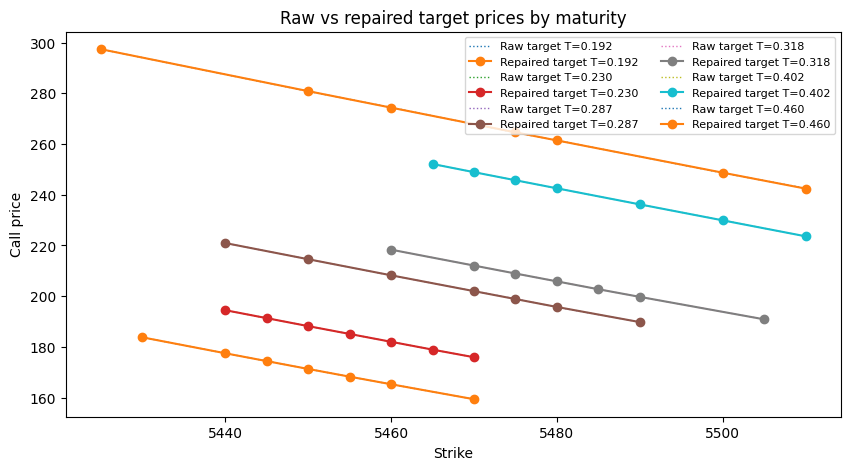

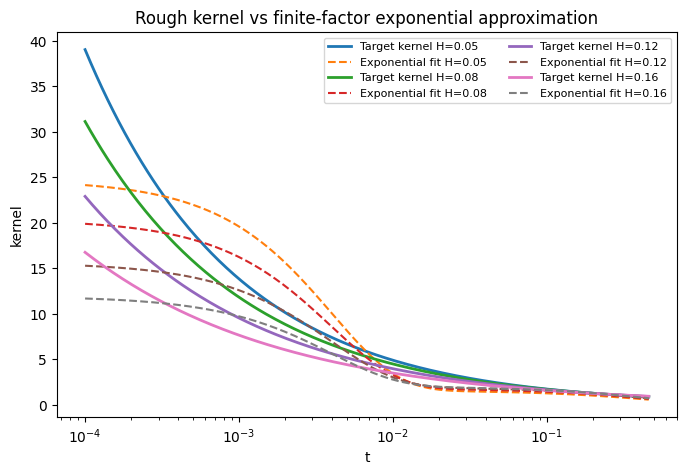

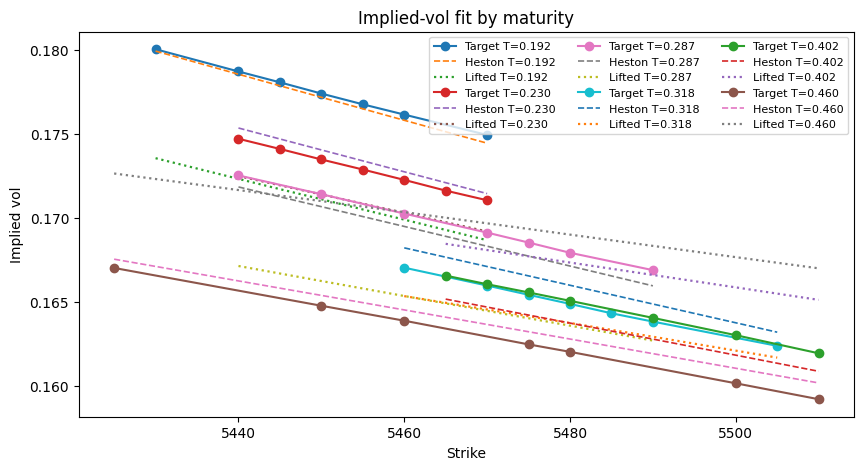

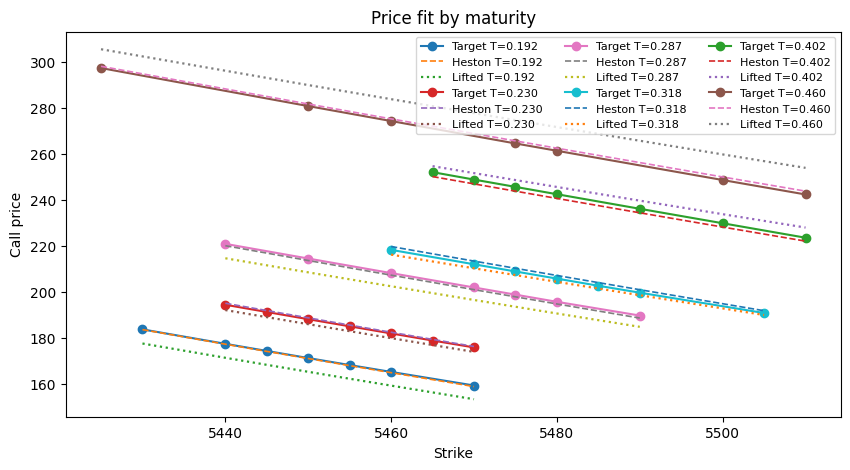

In [9]:

fig, ax = plt.subplots(figsize=(10, 5))
if "price_raw" in heston_targets.columns:
    for T in sorted(heston_targets["T"].unique()):
        sl = heston_targets.loc[heston_targets["T"] == T].sort_values("K")
        ax.plot(sl["K"], sl["price_raw"], linestyle=":", linewidth=1.0, label=f"Raw target T={T:.3f}")
        ax.plot(sl["K"], sl["price"], marker="o", linewidth=1.5, label=f"Repaired target T={T:.3f}")
    ax.set_title("Raw vs repaired target prices by maturity")
    ax.set_xlabel("Strike")
    ax.set_ylabel("Call price")
    ax.legend(ncol=2, fontsize=8)
    plt.show()


fig, ax = plt.subplots(figsize=(8, 5))
for H in sorted(kernel_diagnostics["H"].unique()):
    sl = kernel_diagnostics.loc[kernel_diagnostics["H"] == H].sort_values("t")
    ax.plot(sl["t"], sl["kernel_target"], linewidth=2, label=f"Target kernel H={H:.2f}")
    ax.plot(sl["t"], sl["kernel_fit"], linestyle="--", label=f"Exponential fit H={H:.2f}")
ax.set_xscale("log")
ax.set_title("Rough kernel vs finite-factor exponential approximation")
ax.set_xlabel("t")
ax.set_ylabel("kernel")
ax.legend(ncol=2, fontsize=8)
plt.show()

fig, ax = plt.subplots(figsize=(10, 5))
for T in sorted(heston_targets["T"].unique()):
    tgt = heston_targets.loc[heston_targets["T"] == T].sort_values("K")
    hes = heston_fit.loc[heston_fit["T"] == T].sort_values("K")
    lif = lifted_fit.loc[lifted_fit["T"] == T].sort_values("K")

    ax.plot(tgt["K"], tgt["iv"], marker="o", linewidth=1.5, label=f"Target T={T:.3f}")
    ax.plot(hes["K"], hes["model_iv"], linestyle="--", linewidth=1.2, label=f"Heston T={T:.3f}")
    ax.plot(lif["K"], lif["model_iv"], linestyle=":", linewidth=1.6, label=f"Lifted T={T:.3f}")

ax.set_title("Implied-vol fit by maturity")
ax.set_xlabel("Strike")
ax.set_ylabel("Implied vol")
ax.legend(ncol=3, fontsize=8)
plt.show()

fig, ax = plt.subplots(figsize=(10, 5))
for T in sorted(heston_targets["T"].unique()):
    tgt = heston_targets.loc[heston_targets["T"] == T].sort_values("K")
    hes = heston_fit.loc[heston_fit["T"] == T].sort_values("K")
    lif = lifted_fit.loc[lifted_fit["T"] == T].sort_values("K")

    ax.plot(tgt["K"], tgt["price"], marker="o", linewidth=1.5, label=f"Target T={T:.3f}")
    ax.plot(hes["K"], hes["model_price"], linestyle="--", linewidth=1.2, label=f"Heston T={T:.3f}")
    ax.plot(lif["K"], lif["model_price"], linestyle=":", linewidth=1.6, label=f"Lifted T={T:.3f}")

ax.set_title("Price fit by maturity")
ax.set_xlabel("Strike")
ax.set_ylabel("Call price")
ax.legend(ncol=3, fontsize=8)
plt.show()


## 6.4 Forward / parity diagnostics

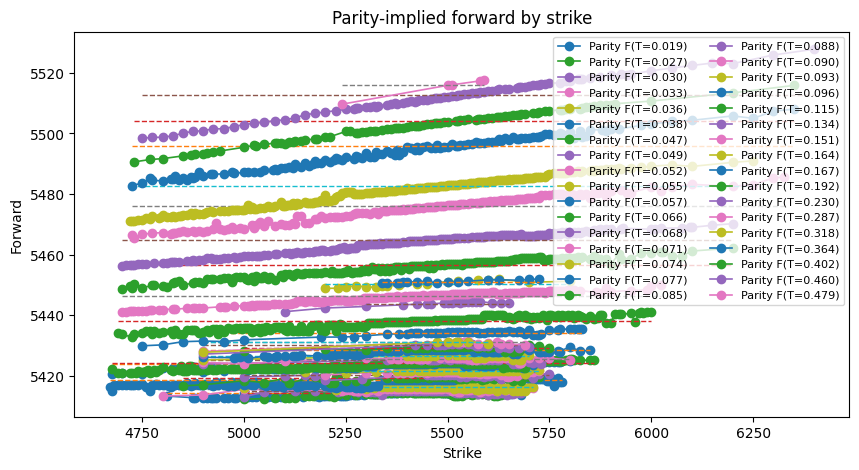

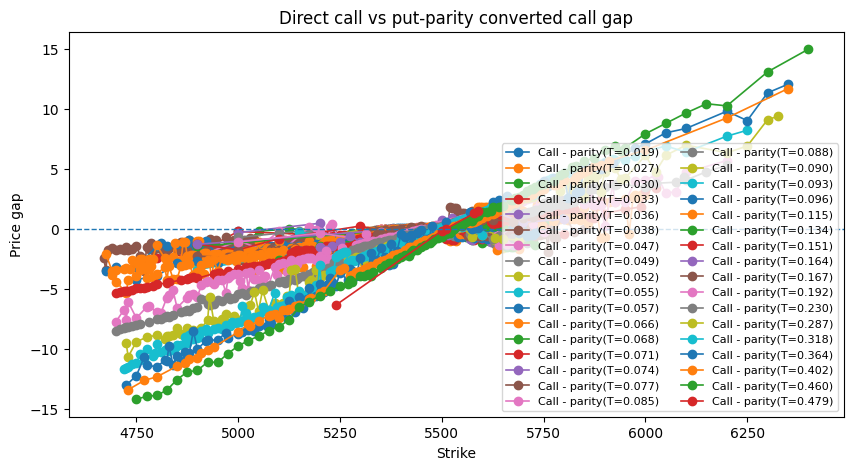

In [10]:

if isinstance(parity_detail, pd.DataFrame) and not parity_detail.empty:
    fig, ax = plt.subplots(figsize=(10, 5))
    for T in sorted(parity_detail["T"].unique()):
        sl = parity_detail.loc[parity_detail["T"] == T].sort_values("strike")
        ax.plot(sl["strike"], sl["F_parity_obs"], marker="o", linewidth=1.2, label=f"Parity F(T={T:.3f})")
        if "F_anchor" in sl.columns:
            ax.plot(sl["strike"], np.full(len(sl), float(np.nanmedian(sl["F_anchor"]))), linestyle="--", linewidth=1.0)
    ax.set_title("Parity-implied forward by strike")
    ax.set_xlabel("Strike")
    ax.set_ylabel("Forward")
    ax.legend(ncol=2, fontsize=8)
    plt.show()

    fig, ax = plt.subplots(figsize=(10, 5))
    for T in sorted(parity_detail["T"].unique()):
        sl = parity_detail.loc[parity_detail["T"] == T].sort_values("strike")
        ax.plot(sl["strike"], sl["call_put_gap"], marker="o", linewidth=1.2, label=f"Call - parity(T={T:.3f})")
    ax.axhline(0.0, linestyle="--", linewidth=1.0)
    ax.set_title("Direct call vs put-parity converted call gap")
    ax.set_xlabel("Strike")
    ax.set_ylabel("Price gap")
    ax.legend(ncol=2, fontsize=8)
    plt.show()
else:
    print("Parity diagnostics unavailable for this run.")


## 6.5 3D volatility-surface visualisation

These plots give a quick shape check for the cleaned target surface and the fitted Heston and lifted-Heston surfaces.  
Use them to spot smile twists, maturity humps, and any remaining weird kinks that 2D slices can hide.


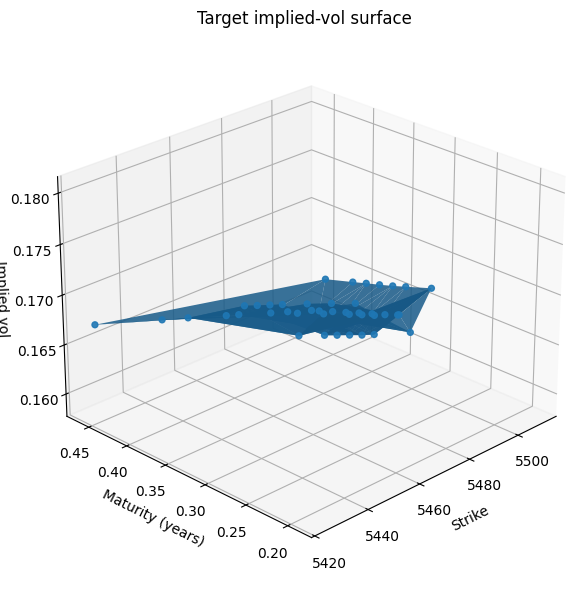

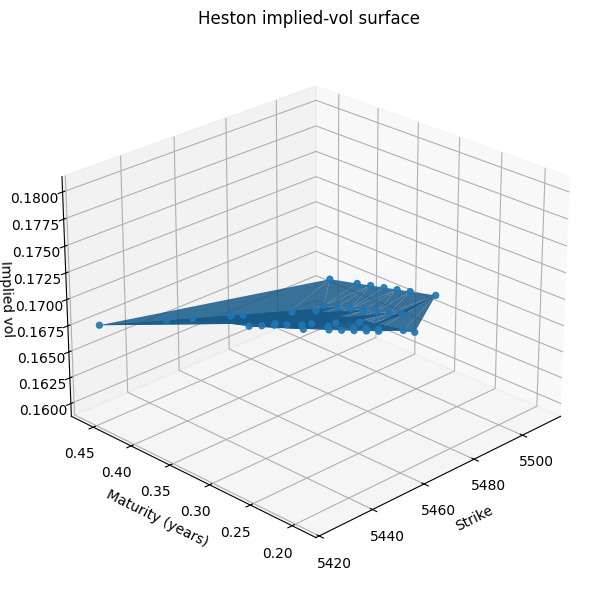

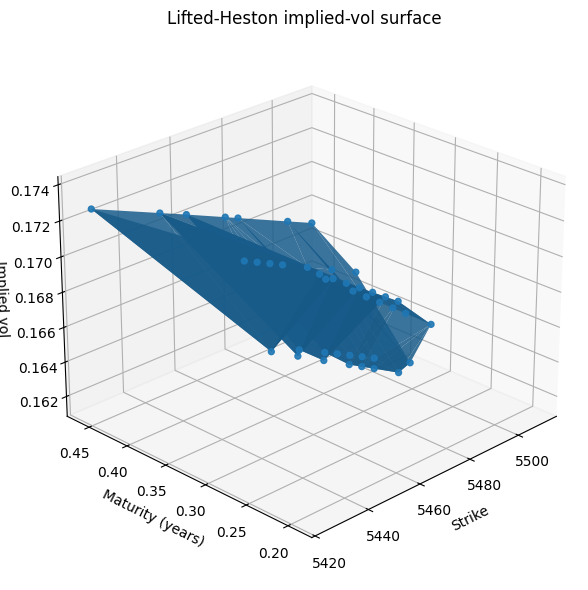

In [11]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

def plot_iv_surface(df, iv_col, title, output_name=None):
    surf = df[["K", "T", iv_col]].dropna().copy()
    surf = surf.sort_values(["T", "K"])
    if len(surf) < 3:
        print(f"Skipping {title}: not enough points for a surface plot.")
        return

    fig = plt.figure(figsize=(9, 6))
    ax = fig.add_subplot(111, projection="3d")
    ax.plot_trisurf(surf["K"], surf["T"], surf[iv_col], linewidth=0.2, alpha=0.85)
    ax.scatter(surf["K"], surf["T"], surf[iv_col], s=18, alpha=0.9)
    ax.set_title(title)
    ax.set_xlabel("Strike")
    ax.set_ylabel("Maturity (years)")
    ax.set_zlabel("Implied vol")
    ax.view_init(elev=25, azim=-135)
    plt.tight_layout()

    if output_name is not None:
        fig.savefig(OUTPUT_DIR / output_name, dpi=180, bbox_inches="tight")
    plt.show()

plot_iv_surface(heston_targets, "iv", "Target implied-vol surface", "iv_surface_target.png")
plot_iv_surface(heston_fit, "model_iv", "Heston implied-vol surface", "iv_surface_heston.png")
plot_iv_surface(lifted_fit, "model_iv", "Lifted-Heston implied-vol surface", "iv_surface_lifted.png")

surface_compare = (
    heston_targets[["K", "T", "iv"]]
    .rename(columns={"iv": "target_iv"})
    .merge(
        heston_fit[["K", "T", "model_iv"]].rename(columns={"model_iv": "heston_iv"}),
        on=["K", "T"],
        how="left",
    )
    .merge(
        lifted_fit[["K", "T", "model_iv"]].rename(columns={"model_iv": "lifted_iv"}),
        on=["K", "T"],
        how="left",
    )
)
surface_compare.to_csv(OUTPUT_DIR / "iv_surface_compare.csv", index=False)
surface_compare.head()


if isinstance(parity_summary, pd.DataFrame) and not parity_summary.empty:
    parity_summary.to_csv(OUTPUT_DIR / "parity_summary.csv", index=False)
if isinstance(parity_detail, pd.DataFrame) and not parity_detail.empty:
    parity_detail.to_csv(OUTPUT_DIR / "parity_detail.csv", index=False)

if surface_noarb_summary_raw is not None:
    with open(OUTPUT_DIR / "surface_noarb_summary_raw.json", "w") as f:
        json.dump(surface_noarb_summary_raw, f, indent=2, default=str)
if isinstance(surface_noarb_detail_raw, pd.DataFrame) and not surface_noarb_detail_raw.empty:
    surface_noarb_detail_raw.to_csv(OUTPUT_DIR / "surface_noarb_detail_raw.csv", index=False)


## 7. Save outputs

Save the essentials plus the cleaning diagnostics:

- fit tables,
- cleaned targets,
- kernel diagnostics,
- surface selection diagnostics,
- simple no-arbitrage summaries.

Because if you do not save the cleaning report, future-you gets to play archaeological detective. Grim little hobby.


In [12]:

summary.to_csv(OUTPUT_DIR / "fit_summary.csv", index=False)
heston_targets.to_csv(OUTPUT_DIR / "calibration_targets.csv", index=False)
heston_fit.to_csv(OUTPUT_DIR / "heston_fit.csv", index=False)
lifted_fit.to_csv(OUTPUT_DIR / "lifted_fit.csv", index=False)
kernel_diagnostics.to_csv(OUTPUT_DIR / "kernel_diagnostics.csv", index=False)

if isinstance(target_diagnostics, pd.DataFrame) and not target_diagnostics.empty:
    target_diagnostics.to_csv(OUTPUT_DIR / "target_diagnostics.csv", index=False)

if isinstance(surface_noarb_detail, pd.DataFrame) and not surface_noarb_detail.empty:
    surface_noarb_detail.to_csv(OUTPUT_DIR / "surface_noarb_detail.csv", index=False)

with open(OUTPUT_DIR / "surface_noarb_summary.json", "w") as f:
    json.dump(surface_noarb_summary, f, indent=2, default=str)

with open(OUTPUT_DIR / "calibration_meta.json", "w") as f:
    json.dump(calibration_meta, f, indent=2, default=str)

with open(OUTPUT_DIR / "heston_params.json", "w") as f:
    json.dump(heston_params, f, indent=2, default=str)

with open(OUTPUT_DIR / "lifted_params.json", "w") as f:
    json.dump(lifted_params, f, indent=2, default=str)

print("Saved outputs to:", OUTPUT_DIR.resolve())


if isinstance(parity_summary, pd.DataFrame) and not parity_summary.empty:
    parity_summary.to_csv(OUTPUT_DIR / "parity_summary.csv", index=False)
if isinstance(parity_detail, pd.DataFrame) and not parity_detail.empty:
    parity_detail.to_csv(OUTPUT_DIR / "parity_detail.csv", index=False)

if surface_noarb_summary_raw is not None:
    with open(OUTPUT_DIR / "surface_noarb_summary_raw.json", "w") as f:
        json.dump(surface_noarb_summary_raw, f, indent=2, default=str)
if isinstance(surface_noarb_detail_raw, pd.DataFrame) and not surface_noarb_detail_raw.empty:
    surface_noarb_detail_raw.to_csv(OUTPUT_DIR / "surface_noarb_detail_raw.csv", index=False)


Saved outputs to: C:\Users\lhkke\OneDrive - Queen Mary, University of London\Documents\Dissertation\Deep-Hedging-under-Lifted-Heston-MSc-Dissertation-\lifted_heston_calibration_outputs


## What changed

- Added a hard no-arbitrage repair step on the candidate call surface before calibration.
- Added forward / parity diagnostic tables and plots.
- Increased the weighted calibration set to 7 strikes per maturity and up to 12 candidate strikes per maturity.
- Preserved raw prices and vols alongside repaired values so the effect of the cleaning is visible.

## Next step

Rerun the notebook from Section 5 onward and compare raw vs repaired no-arbitrage diagnostics, parity stability, and the larger 7-strike weighted calibration fit.

# Part A extension: short-end traded maturities and wide calibration windows

This extension keeps the original cleaning and parity / no-arbitrage logic, but adds two targeted experiments:

1. **Short-end traded maturities** via a `1w` bucket alongside the existing `2w`, `1m`, and `2m` buckets.
2. **Wide calibration windows** that force the model to explain short, medium, and longer maturities together rather than just a more local patch.

The baseline 30d-style setup is preserved and labelled explicitly, so the notebook can answer:

- does lifted Heston become more useful when the **trade itself** is shorter-dated?
- does lifted Heston improve when calibration uses a **broader maturity range**?


In [13]:
# Part A → Part B panel handoff configuration for short-end and wide-calibration tests
BASELINE_BUCKET_SPECS = (
    {"maturity_bucket": "2w", "target_dte": 14, "dte_window": (10, 20), "relaxed_window": (7, 28), "max_abs_log_moneyness": 0.025, "max_total_rel_spread": 0.30},
    {"maturity_bucket": "1m", "target_dte": 30, "dte_window": (24, 38), "relaxed_window": (18, 45), "max_abs_log_moneyness": 0.030, "max_total_rel_spread": 0.35},
    {"maturity_bucket": "2m", "target_dte": 60, "dte_window": (45, 75), "relaxed_window": (35, 90), "max_abs_log_moneyness": 0.035, "max_total_rel_spread": 0.40},
)

SHORT_END_BUCKET_SPECS = (
    {"maturity_bucket": "1w", "target_dte": 7, "dte_window": (5, 10), "relaxed_window": (4, 12), "max_abs_log_moneyness": 0.020, "max_total_rel_spread": 0.22},
    {"maturity_bucket": "2w", "target_dte": 14, "dte_window": (10, 20), "relaxed_window": (7, 28), "max_abs_log_moneyness": 0.025, "max_total_rel_spread": 0.28},
)

CALIBRATION_WINDOW_SPECS = {
    "local": {
        "calibration_window_mode": "local",
        "calibration_dte_range": None,
        "max_maturities": int(CFG.max_maturities),
        "strikes_per_maturity": int(CFG.strikes_per_maturity),
    },
    "wide": {
        "calibration_window_mode": "wide",
        "calibration_dte_range": (5, 120),
        "max_maturities": max(int(CFG.max_maturities) + 3, 8),
        "strikes_per_maturity": int(CFG.strikes_per_maturity),
    },
}

EPISODE_EXPERIMENT_SPECS = (
    {
        "experiment_id": "baseline_local",
        "trade_experiment": "baseline",
        "bucket_specs": BASELINE_BUCKET_SPECS,
        "calibration_spec": CALIBRATION_WINDOW_SPECS["local"],
    },
    {
        "experiment_id": "short_end_local",
        "trade_experiment": "short_end",
        "bucket_specs": SHORT_END_BUCKET_SPECS,
        "calibration_spec": CALIBRATION_WINDOW_SPECS["local"],
    },
    {
        "experiment_id": "baseline_wide",
        "trade_experiment": "baseline",
        "bucket_specs": BASELINE_BUCKET_SPECS,
        "calibration_spec": CALIBRATION_WINDOW_SPECS["wide"],
    },
)

EPISODE_TARGET_DATES = 24
EPISODE_MAX_SEEDS = 144
EPISODE_REQUIRE_LIFTED_SUCCESS = False

EPISODE_OUTPUT_PATH = Path("/mnt/data/episode_seeds_v15_short_wide.csv")
EPISODE_DIAG_PATH = Path("/mnt/data/episode_seed_selection_diagnostics_v15_short_wide.csv")
EPISODE_FIT_SUMMARY_PATH = Path("/mnt/data/episode_fit_summaries_v15_short_wide.csv")


In [14]:
def _pick_spot_for_date(dt: pd.Timestamp, crsp: pd.DataFrame, fallback: float) -> float:
    if crsp is not None and not crsp.empty:
        row = crsp.loc[crsp["date"] == pd.Timestamp(dt)]
        if not row.empty and "spindx" in row.columns and pd.notna(row["spindx"].iloc[0]):
            return float(row["spindx"].iloc[0])
    return float(fallback)

def _pair_calls_and_puts(option_day: pd.DataFrame) -> pd.DataFrame:
    day = option_day.copy()
    if day.empty:
        return pd.DataFrame()

    day["date"] = pd.to_datetime(day["date"])
    day["exdate"] = pd.to_datetime(day["exdate"])
    day["cp_side"] = day["cp_flag"].astype(str).str.upper().str[0]
    day["T"] = year_fraction_from_calendar_days(day["dte"], CFG.calendar_days_per_year)

    cols = ["date", "exdate", "dte", "T", "strike", "mid", "spread", "rel_spread", "delta", "impl_volatility", "forward_price"]
    calls = (
        day.loc[day["cp_side"] == "C", cols]
        .rename(columns={
            "mid": "call_mid",
            "spread": "call_spread",
            "rel_spread": "call_rel_spread",
            "delta": "call_delta",
            "impl_volatility": "call_vendor_iv",
            "forward_price": "call_forward_price",
        })
    )
    puts = (
        day.loc[day["cp_side"] == "P", cols]
        .rename(columns={
            "mid": "put_mid",
            "spread": "put_spread",
            "rel_spread": "put_rel_spread",
            "delta": "put_delta",
            "impl_volatility": "put_vendor_iv",
            "forward_price": "put_forward_price",
        })
    )

    pairs = calls.merge(puts, on=["date", "exdate", "dte", "T", "strike"], how="inner")
    if pairs.empty:
        return pairs

    pairs["call_bid_proxy"] = pairs["call_mid"] - 0.5 * pairs["call_spread"]
    pairs["call_ask_proxy"] = pairs["call_mid"] + 0.5 * pairs["call_spread"]
    pairs["put_bid_proxy"] = pairs["put_mid"] - 0.5 * pairs["put_spread"]
    pairs["put_ask_proxy"] = pairs["put_mid"] + 0.5 * pairs["put_spread"]
    pairs["straddle_mid"] = pairs["call_mid"] + pairs["put_mid"]
    pairs["straddle_spread"] = pairs["call_spread"] + pairs["put_spread"]
    pairs["total_rel_spread"] = pairs["call_rel_spread"].fillna(0.0) + pairs["put_rel_spread"].fillna(0.0)
    return pairs.sort_values(["dte", "strike"]).reset_index(drop=True)

def select_trade_candidate_from_clean_day(
    option_day: pd.DataFrame,
    S0: float,
    r: float,
    q: float,
    target_dte: int,
    dte_window: tuple[int, int],
    relaxed_window: tuple[int, int],
    max_abs_log_moneyness: float,
    maturity_bucket: str,
    max_total_rel_spread: float | None = None,
):
    pairs = _pair_calls_and_puts(option_day)
    if pairs.empty:
        return None, pd.DataFrame()

    F_ref = pairs["call_forward_price"].combine_first(pairs["put_forward_price"])
    fallback_F = S0 * np.exp((r - q) * pairs["T"])
    pairs["F_ref"] = F_ref.fillna(fallback_F)
    pairs["log_moneyness"] = np.log(np.maximum(pairs["strike"], 1e-12) / np.maximum(pairs["F_ref"], 1e-12))
    pairs["abs_log_moneyness"] = pairs["log_moneyness"].abs()
    pairs["dte_gap"] = (pairs["dte"] - target_dte).abs()
    pairs["maturity_bucket"] = maturity_bucket
    pairs["target_dte"] = int(target_dte)

    liquidity_mask = np.ones(len(pairs), dtype=bool)
    if max_total_rel_spread is not None and np.isfinite(max_total_rel_spread):
        liquidity_mask &= pd.to_numeric(pairs["total_rel_spread"], errors="coerce").fillna(np.inf).to_numpy() <= float(max_total_rel_spread)

    strict = pairs.loc[
        liquidity_mask
        & pairs["dte"].between(*dte_window)
        & (pairs["abs_log_moneyness"] <= float(max_abs_log_moneyness))
    ].copy()
    selection_tier = "strict"

    if strict.empty:
        strict = pairs.loc[liquidity_mask & pairs["dte"].between(*relaxed_window)].copy()
        selection_tier = "relaxed_window" if not strict.empty else "nearest_available"

    candidates = strict if not strict.empty else pairs.loc[liquidity_mask].copy()
    if candidates.empty:
        candidates = pairs.copy()
        selection_tier = "nearest_available_all"

    candidates = candidates.sort_values(
        ["dte_gap", "abs_log_moneyness", "total_rel_spread", "straddle_spread", "strike"]
    ).reset_index(drop=True)

    best = candidates.iloc[0].copy()
    best["selection_tier"] = selection_tier
    return best, candidates


def _fit_error_summary(fit_df: pd.DataFrame, prefix: str) -> dict:
    if fit_df is None or fit_df.empty:
        return {
            f"{prefix}_n_fit_points": 0,
            f"{prefix}_median_abs_iv_error": np.nan,
            f"{prefix}_mean_abs_iv_error": np.nan,
            f"{prefix}_median_abs_rel_price_error": np.nan,
            f"{prefix}_mean_abs_rel_price_error": np.nan,
        }

    if "abs_iv_error" in fit_df.columns:
        iv_abs = pd.to_numeric(fit_df["abs_iv_error"], errors="coerce")
    elif "iv_error" in fit_df.columns:
        iv_abs = pd.to_numeric(fit_df["iv_error"], errors="coerce").abs()
    else:
        iv_abs = pd.Series(np.nan, index=fit_df.index, dtype=float)

    if "abs_rel_price_error" in fit_df.columns:
        rel_abs = pd.to_numeric(fit_df["abs_rel_price_error"], errors="coerce")
    elif "rel_price_error" in fit_df.columns:
        rel_abs = pd.to_numeric(fit_df["rel_price_error"], errors="coerce").abs()
    else:
        rel_abs = pd.Series(np.nan, index=fit_df.index, dtype=float)

    return {
        f"{prefix}_n_fit_points": int(len(fit_df)),
        f"{prefix}_median_abs_iv_error": float(iv_abs.median()),
        f"{prefix}_mean_abs_iv_error": float(iv_abs.mean()),
        f"{prefix}_median_abs_rel_price_error": float(rel_abs.median()),
        f"{prefix}_mean_abs_rel_price_error": float(rel_abs.mean()),
    }

def reduce_surface_for_calibration_mode(
    targets: pd.DataFrame,
    S0: float,
    mode: str = "local",
    max_maturities: int = 5,
    strikes_per_maturity: int = 5,
    trade_focus_dte: int | None = None,
    calibration_dte_range: tuple[int, int] | None = None,
):
    x = deduplicate_surface_points(targets, key_cols=("T", "K"))
    if x.empty:
        return x

    if calibration_dte_range is not None and "dte" in x.columns:
        x = x.loc[x["dte"].between(int(calibration_dte_range[0]), int(calibration_dte_range[1]))].copy()
        if x.empty:
            return x

    x["m_gap"] = np.abs(np.log(np.maximum(x["K"], 1e-12) / max(S0, 1e-12)))
    if "fit_weight" not in x.columns:
        x["fit_weight"] = 1.0
    rel_spread_fill = x["rel_spread"].fillna(x["rel_spread"].median()) if "rel_spread" in x.columns else 0.0
    x["selection_score"] = x["fit_weight"] / (1.0 + 2.0 * x["m_gap"] + 10.0 * rel_spread_fill)

    keep_all_threshold = max(30, int(max_maturities * strikes_per_maturity * 1.5))
    if len(x) <= keep_all_threshold:
        return x.sort_values(["T", "K"]).reset_index(drop=True)

    maturity_scores = x.groupby("dte")["selection_score"].sum().sort_values(ascending=False)
    chosen_dtes: list[int] = []

    if str(mode) == "wide":
        unique_dtes = np.array(sorted(maturity_scores.index.tolist()), dtype=int)
        for block in np.array_split(unique_dtes, 3):
            if len(block) == 0:
                continue
            block_scores = maturity_scores.loc[list(block)].sort_values(ascending=False)
            chosen_dtes.extend(block_scores.head(max(1, int(math.ceil(max_maturities / 3)))).index.tolist())
        for d in maturity_scores.index.tolist():
            if d not in chosen_dtes:
                chosen_dtes.append(int(d))
            if len(chosen_dtes) >= int(max_maturities):
                break
        chosen_dtes = chosen_dtes[: int(max_maturities)]
    else:
        local_scores = maturity_scores.copy()
        if trade_focus_dte is not None:
            focus_gap = np.abs(local_scores.index.to_numpy(dtype=float) - float(trade_focus_dte))
            local_scores = local_scores / (1.0 + 0.08 * focus_gap)
        chosen_dtes = local_scores.sort_values(ascending=False).index.tolist()[: int(max_maturities)]

    x = x.loc[x["dte"].isin(chosen_dtes)].copy()
    x = (
        x.sort_values(["dte", "selection_score", "m_gap", "price"], ascending=[True, False, True, True])
        .groupby("dte", group_keys=False)
        .head(int(strikes_per_maturity))
    )
    return deduplicate_surface_points(x.sort_values(["T", "K"]).reset_index(drop=True), key_cols=("T", "K"))

def build_episode_seeds_for_date(
    dt: pd.Timestamp,
    option_path: Path,
    crsp: pd.DataFrame,
    experiment_spec: dict,
    cfg: CalibrationConfig = CFG,
):
    dt = pd.Timestamp(dt)
    bucket_specs = tuple(experiment_spec["bucket_specs"])
    calibration_spec = dict(experiment_spec["calibration_spec"])
    calibration_mode = str(calibration_spec["calibration_window_mode"])

    opt_day = load_option_data_for_dates(option_path, [dt], cfg=cfg)
    if opt_day is None or opt_day.empty:
        return [], pd.DataFrame(), pd.DataFrame()

    relaxed_lo = min(int(b["relaxed_window"][0]) for b in bucket_specs)
    relaxed_hi = max(int(b["relaxed_window"][1]) for b in bucket_specs)
    calib_range = calibration_spec.get("calibration_dte_range")
    load_lo = min(relaxed_lo, int(calib_range[0]) if calib_range is not None else relaxed_lo)
    load_hi = max(relaxed_hi, int(calib_range[1]) if calib_range is not None else relaxed_hi)

    opt_day = opt_day.loc[
        opt_day["usable_quote"] & opt_day["dte"].between(load_lo, load_hi)
    ].copy()
    if opt_day.empty:
        return [], pd.DataFrame(), pd.DataFrame()

    market_targets_dt, meta_dt, _ = build_market_targets(opt_day, crsp=crsp, cfg=cfg)
    if market_targets_dt is None or len(market_targets_dt) < cfg.min_points:
        return [], pd.DataFrame(), pd.DataFrame()

    S0_dt = float(meta_dt["S0"])
    r_dt = float(meta_dt["r"])
    q_dt = float(meta_dt.get("q", 0.0))

    bundle_cache: dict[tuple, dict] = {}
    fit_rows = []
    seed_rows = []
    diag_frames = []

    for spec in bucket_specs:
        selected_trade, trade_diag = select_trade_candidate_from_clean_day(
            opt_day,
            S0=S0_dt,
            r=r_dt,
            q=q_dt,
            target_dte=int(spec["target_dte"]),
            dte_window=tuple(spec["dte_window"]),
            relaxed_window=tuple(spec["relaxed_window"]),
            max_abs_log_moneyness=float(spec["max_abs_log_moneyness"]),
            maturity_bucket=str(spec["maturity_bucket"]),
            max_total_rel_spread=float(spec.get("max_total_rel_spread", np.nan)) if spec.get("max_total_rel_spread") is not None else None,
        )
        if selected_trade is None:
            continue

        cache_key = (
            calibration_mode,
            int(spec["target_dte"]) if calibration_mode == "local" else "wide",
        )
        if cache_key not in bundle_cache:
            calibration_targets_dt = reduce_surface_for_calibration_mode(
                market_targets_dt,
                S0=S0_dt,
                mode=calibration_mode,
                max_maturities=int(calibration_spec["max_maturities"]),
                strikes_per_maturity=int(calibration_spec["strikes_per_maturity"]),
                trade_focus_dte=int(spec["target_dte"]) if calibration_mode == "local" else None,
                calibration_dte_range=tuple(calibration_spec["calibration_dte_range"]) if calibration_spec.get("calibration_dte_range") is not None else None,
            )
            if calibration_targets_dt is None or len(calibration_targets_dt) < cfg.min_points:
                continue
            heston_params_dt, heston_fit_dt = calibrate_heston_warm_start(calibration_targets_dt, S0=S0_dt, r=r_dt, q=q_dt, cfg=cfg)
            lifted_params_dt, lifted_fit_dt, _ = calibrate_lifted_heston(
                calibration_targets_dt, S0=S0_dt, r=r_dt, q=q_dt, heston_init=heston_params_dt, cfg=cfg,
            )
            bundle_cache[cache_key] = {
                "targets": calibration_targets_dt,
                "heston_params": heston_params_dt,
                "heston_fit": heston_fit_dt,
                "lifted_params": lifted_params_dt,
                "lifted_fit": lifted_fit_dt,
            }

        bundle = bundle_cache.get(cache_key)
        if bundle is None:
            continue

        base_seed = {
            "trade_date": str(dt.date()),
            "experiment_id": str(experiment_spec["experiment_id"]),
            "trade_experiment": str(experiment_spec["trade_experiment"]),
            "calibration_window_mode": calibration_mode,
            "spot_entry": S0_dt,
            "r": r_dt,
            "q": q_dt,
            "heston_kappa": float(bundle["heston_params"]["kappa"]),
            "heston_theta": float(bundle["heston_params"]["theta"]),
            "heston_sigma": float(bundle["heston_params"]["sigma"]),
            "heston_rho": float(bundle["heston_params"]["rho"]),
            "heston_v0": float(bundle["heston_params"]["v0"]),
            "lifted_H": float(bundle["lifted_params"]["H"]),
            "lifted_kappa": float(bundle["lifted_params"]["kappa"]),
            "lifted_theta": float(bundle["lifted_params"]["theta"]),
            "lifted_nu": float(bundle["lifted_params"]["nu"]),
            "lifted_rho": float(bundle["lifted_params"]["rho"]),
            "lifted_V0": float(bundle["lifted_params"]["V0"]),
            "lifted_n_factors": int(bundle["lifted_params"]["n_factors"]),
            "lifted_success": bool(bundle["lifted_params"]["success"]),
            "lifted_score": float(bundle["lifted_params"]["score"]),
            "calibration_target_points": int(len(bundle["targets"])),
            "calibration_maturity_min_dte": float(pd.to_numeric(bundle["targets"]["dte"], errors="coerce").min()),
            "calibration_maturity_max_dte": float(pd.to_numeric(bundle["targets"]["dte"], errors="coerce").max()),
            "calibration_n_maturities": int(pd.Series(bundle["targets"]["dte"]).nunique()),
        }
        base_seed.update(_fit_error_summary(bundle["heston_fit"], "heston"))
        base_seed.update(_fit_error_summary(bundle["lifted_fit"], "lifted"))

        entry_iv = float(np.nanmean([
            selected_trade.get("call_vendor_iv", np.nan),
            selected_trade.get("put_vendor_iv", np.nan),
        ]))
        if not np.isfinite(entry_iv):
            entry_iv = float(np.sqrt(max(base_seed.get("heston_v0", np.nan), 1e-12))) if np.isfinite(base_seed.get("heston_v0", np.nan)) else np.nan

        seed = dict(base_seed)
        seed.update({
            "seed_id": f"{experiment_spec['experiment_id']}_{dt.date()}_{spec['maturity_bucket']}",
            "maturity_bucket": str(spec["maturity_bucket"]),
            "target_dte": int(spec["target_dte"]),
            "expiry": str(pd.Timestamp(selected_trade["exdate"]).date()),
            "dte": float(selected_trade["dte"]),
            "T": float(selected_trade["T"]),
            "strike": float(selected_trade["strike"]),
            "forward_ref": float(selected_trade["F_ref"]),
            "log_moneyness": float(selected_trade["log_moneyness"]),
            "selection_tier": selected_trade["selection_tier"],
            "entry_iv": entry_iv,
            "call_vendor_iv": float(selected_trade.get("call_vendor_iv", np.nan)),
            "put_vendor_iv": float(selected_trade.get("put_vendor_iv", np.nan)),
            "call_entry_mid": float(selected_trade["call_mid"]),
            "put_entry_mid": float(selected_trade["put_mid"]),
            "call_bid_proxy": float(selected_trade["call_bid_proxy"]),
            "call_ask_proxy": float(selected_trade["call_ask_proxy"]),
            "put_bid_proxy": float(selected_trade["put_bid_proxy"]),
            "put_ask_proxy": float(selected_trade["put_ask_proxy"]),
            "straddle_entry_mid": float(selected_trade["straddle_mid"]),
            "straddle_spread": float(selected_trade["straddle_spread"]),
            "call_rel_spread": float(selected_trade["call_rel_spread"]),
            "put_rel_spread": float(selected_trade["put_rel_spread"]),
            "pair_count_bucket": int(len(trade_diag)),
            "short_end_quality_flag": bool(int(spec["target_dte"]) <= 14 and float(selected_trade.get("total_rel_spread", 0.0)) <= float(spec.get("max_total_rel_spread", 0.30))),
        })
        if EPISODE_REQUIRE_LIFTED_SUCCESS and (not seed["lifted_success"]):
            continue

        fit_rows.extend([
            {
                "trade_date": str(dt.date()),
                "experiment_id": str(experiment_spec["experiment_id"]),
                "trade_experiment": str(experiment_spec["trade_experiment"]),
                "calibration_window_mode": calibration_mode,
                "maturity_bucket": str(spec["maturity_bucket"]),
                "model": "Heston",
                **_fit_error_summary(bundle["heston_fit"], "fit"),
            },
            {
                "trade_date": str(dt.date()),
                "experiment_id": str(experiment_spec["experiment_id"]),
                "trade_experiment": str(experiment_spec["trade_experiment"]),
                "calibration_window_mode": calibration_mode,
                "maturity_bucket": str(spec["maturity_bucket"]),
                "model": "LiftedHeston",
                **_fit_error_summary(bundle["lifted_fit"], "fit"),
            },
        ])

        trade_diag = trade_diag.copy()
        for col, value, loc in [
            ("trade_date", str(dt.date()), 0),
            ("experiment_id", str(experiment_spec["experiment_id"]), 1),
            ("trade_experiment", str(experiment_spec["trade_experiment"]), 2),
            ("calibration_window_mode", calibration_mode, 3),
            ("maturity_bucket", str(spec["maturity_bucket"]), 4),
        ]:
            if col in trade_diag.columns:
                trade_diag[col] = value
            else:
                trade_diag.insert(min(loc, len(trade_diag.columns)), col, value)
        diag_frames.append(trade_diag)
        seed_rows.append(seed)

    diag_df = pd.concat(diag_frames, ignore_index=True) if diag_frames else pd.DataFrame()
    fit_summary_df = pd.DataFrame(fit_rows)
    return seed_rows, diag_df, fit_summary_df

def rank_episode_candidate_dates(target_diagnostics: pd.DataFrame, top_dates: int = EPISODE_TARGET_DATES) -> list[pd.Timestamp]:
    if target_diagnostics is None or target_diagnostics.empty or "date" not in target_diagnostics.columns:
        return []

    x = target_diagnostics.copy()
    x["date"] = pd.to_datetime(x["date"], errors="coerce")
    x = x.loc[x["date"].notna()].copy()
    if x.empty:
        return []

    score = np.zeros(len(x), dtype=float)
    penalties = {
        "n_vertical_violations": 100.0,
        "n_butterfly_violations": 10.0,
        "n_calendar_violations": 100.0,
    }
    rewards = {
        "n_target_points": 0.05,
        "parity_anchor_count": 0.50,
        "parity_pair_count": 0.01,
    }

    for col, w in penalties.items():
        if col in x.columns:
            score += w * pd.to_numeric(x[col], errors="coerce").fillna(0.0).to_numpy()
    for col, w in rewards.items():
        if col in x.columns:
            score -= w * pd.to_numeric(x[col], errors="coerce").fillna(0.0).to_numpy()

    x["episode_rank_score"] = score
    x = x.sort_values(["episode_rank_score", "date"]).drop_duplicates(subset=["date"], keep="first")
    return x["date"].head(int(top_dates)).tolist()

def expand_episode_candidate_dates(
    target_diagnostics: pd.DataFrame,
    option_path: Path,
    cfg: CalibrationConfig = CFG,
    needed_dates: int = EPISODE_TARGET_DATES,
):
    ranked = rank_episode_candidate_dates(target_diagnostics, top_dates=max(int(needed_dates), 1))
    ranked = [pd.Timestamp(d).normalize() for d in ranked if pd.notna(d)]
    if len(ranked) >= int(needed_dates) or option_path is None:
        return ranked[: int(needed_dates)]

    scored = scan_option_candidate_dates(option_path, cfg=cfg)
    extra = []
    seen = {pd.Timestamp(d).normalize() for d in ranked}
    for dt in pd.to_datetime(scored.get("date", pd.Series([], dtype="datetime64[ns]")), errors="coerce").dropna():
        dtn = pd.Timestamp(dt).normalize()
        if dtn not in seen:
            extra.append(dtn)
            seen.add(dtn)
        if len(ranked) + len(extra) >= int(needed_dates):
            break

    return (ranked + extra)[: int(needed_dates)]


In [ ]:
# Build the short-end and wide-calibration experiment panel.
candidate_dates = expand_episode_candidate_dates(
    target_diagnostics if "target_diagnostics" in globals() else None,
    OPTION_PATH,
    cfg=CFG,
    needed_dates=EPISODE_TARGET_DATES,
)

episode_seed_rows = []
episode_diag_frames = []
episode_fit_frames = []

for experiment_spec in EPISODE_EXPERIMENT_SPECS:
    print(f"=== Experiment {experiment_spec['experiment_id']} ({experiment_spec['trade_experiment']}, {experiment_spec['calibration_spec']['calibration_window_mode']}) ===")
    for dt in candidate_dates:
        print(f"Building episode seeds for {pd.Timestamp(dt).date()} ...")
        seed_rows_dt, trade_diag_df, fit_summary_dt = build_episode_seeds_for_date(
            dt,
            OPTION_PATH,
            crsp=crsp,
            experiment_spec=experiment_spec,
            cfg=CFG,
        )
        episode_seed_rows.extend(seed_rows_dt)
        if trade_diag_df is not None and not trade_diag_df.empty:
            episode_diag_frames.append(trade_diag_df)
        if fit_summary_dt is not None and not fit_summary_dt.empty:
            episode_fit_frames.append(fit_summary_dt)

episode_seeds = pd.DataFrame(episode_seed_rows)
episode_seed_selection_diagnostics = pd.concat(episode_diag_frames, ignore_index=True) if episode_diag_frames else pd.DataFrame()
episode_fit_summaries = pd.concat(episode_fit_frames, ignore_index=True) if episode_fit_frames else pd.DataFrame()

if not episode_seeds.empty:
    episode_seeds["trade_date"] = pd.to_datetime(episode_seeds["trade_date"])
    episode_seeds = (
        episode_seeds
        .sort_values(["trade_date", "experiment_id", "target_dte", "strike"])
        .drop_duplicates(subset=["seed_id"], keep="first")
        .head(EPISODE_MAX_SEEDS)
        .reset_index(drop=True)
    )

    if "entry_iv" not in episode_seeds.columns:
        if {"call_vendor_iv", "put_vendor_iv"}.issubset(episode_seeds.columns):
            episode_seeds["entry_iv"] = episode_seeds[["call_vendor_iv", "put_vendor_iv"]].mean(axis=1)
        elif "heston_v0" in episode_seeds.columns:
            episode_seeds["entry_iv"] = np.sqrt(np.maximum(pd.to_numeric(episode_seeds["heston_v0"], errors="coerce"), 1e-12))
        else:
            episode_seeds["entry_iv"] = np.nan

    date_iv = episode_seeds.groupby("trade_date")["entry_iv"].median()
    if date_iv.isna().all():
        date_iv = episode_seeds.groupby("trade_date")["straddle_entry_mid"].median()
    iv_threshold = float(date_iv.median()) if len(date_iv) else np.nan
    episode_seeds["regime_iv_proxy"] = episode_seeds["trade_date"].map(date_iv).astype(float)
    episode_seeds["regime_label"] = np.where(episode_seeds["regime_iv_proxy"] >= iv_threshold, "stressed", "calm")
    episode_seeds["trade_date"] = episode_seeds["trade_date"].dt.strftime("%Y-%m-%d")

if not episode_seeds.empty:
    episode_seeds.to_csv(EPISODE_OUTPUT_PATH, index=False)
if not episode_seed_selection_diagnostics.empty:
    episode_seed_selection_diagnostics.to_csv(EPISODE_DIAG_PATH, index=False)
if not episode_fit_summaries.empty:
    episode_fit_summaries.to_csv(EPISODE_FIT_SUMMARY_PATH, index=False)

display(episode_seeds.head(18))
display(
    episode_seeds.groupby(["experiment_id", "maturity_bucket"], as_index=False)
    .agg(
        n_seeds=("seed_id", "count"),
        min_dte=("dte", "min"),
        max_dte=("dte", "max"),
        avg_entry_iv=("entry_iv", "mean"),
    )
    if not episode_seeds.empty else pd.DataFrame()
)
display(
    episode_seeds.groupby(["experiment_id", "regime_label"], as_index=False)
    .agg(n_seeds=("seed_id", "count"), avg_entry_iv=("entry_iv", "mean"))
    if not episode_seeds.empty else pd.DataFrame()
)
display(episode_fit_summaries.head(18))
display(episode_seed_selection_diagnostics.head(20))
print("n episode seeds:", len(episode_seeds))
print("candidate dates scanned:", len(candidate_dates))
print("target dates:", EPISODE_TARGET_DATES)
print("experiments:", len(EPISODE_EXPERIMENT_SPECS))
print("Saved:", EPISODE_OUTPUT_PATH)
print("Saved:", EPISODE_DIAG_PATH)
print("Saved:", EPISODE_FIT_SUMMARY_PATH)


=== Experiment baseline_local (baseline, local) ===
Building episode seeds for 2024-08-28 ...


## Result of the Part A short-end / wide-calibration extension

This version keeps the cleaning, parity, and no-arbitrage machinery intact, but exports a richer seed panel with explicit experiment labels:

- `baseline_local`
- `short_end_local`
- `baseline_wide`

Each seed now carries:
- the traded maturity bucket
- the trade-experiment label
- the calibration-window label
- calibration-range metadata

This lets Part B ask whether lifted Heston matters more for:

1. **shorter traded maturities**, and
2. **broader term-structure calibration problems**.
